# Introduction

In the previous notebook, we introduced Gaussian processes as distributions over functions and explored how their mean functions and covariance kernels determine prior assumptions. In this notebook, we use Gaussian processes for regression by conditioning a prior process on noisy observations. We derive the posterior mean and covariance, implement inference using `ConditionalGaussianProcess`, and study how data, noise, and kernel hyperparameters affect posterior predictions and uncertainty.

# Imports and Setup

In [1]:
import sys
import warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

warnings.filterwarnings('ignore')
sys.path.append(str(PROJECT_ROOT))

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jax import random
from matplotlib.axes import Axes

from src.gaussian import Gaussian, GaussianProcess

KEY = random.key(47)

# Gaussian Process Regression Model

## Latent Function

Imagine a regression problem with training inputs 
$$ X = (x_1, x_2, \dots, x_n), \quad x_i \in \mathcal{X} $$

Then, the problem is to find an unknown regression function 
$$ f \sim \mathcal{GP}(m, k) $$

From the previous notebook we know that:
$$ f_X := \begin{bmatrix} f(x_1) \\ \vdots \\ f(x_n) \end{bmatrix} \sim \mathcal{N}(m_X, K_{XX}) $$
where
$$ (m_X)_i = m(x_i), \quad (K_{XX})_{ij} = k(x_i, x_j) $$

## Observational Model

Note that $f_X$ defined above does not contain any measurement noise. So we should explicitly add some measurement noise into our observational model:
$$ y_i = f(x_i) + \varepsilon_i, \quad \varepsilon_i \sim \mathcal{N}(0, r^2) $$
or, equivalently,
$$ y = f_X + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, r^2 I) $$

Note that
$$ y \sim \mathcal{N}(m_X, K_{XX} + r^2 I) $$
for further convenience let us define
$$ K_y := K_{XX} + r^2 I $$



## Joint Gaussian Distribution

Now let us obtain the posterior mean and covariance using Joint Gaussian Distribution as we have done in [Bayesian Regression notebook](<2. Bayesian Regression.ipynb>). Let $X_*$ be test inputs. Then, our joint Gaussian is:
$$ \begin{bmatrix} y \\ f_* \end{bmatrix} \sim \mathcal{N} \left( \begin{bmatrix} m_X \\ m_* \end{bmatrix}, \begin{bmatrix} K_{y} & K_{X*} \\ K_{*X} & K_{**} \end{bmatrix} \right) $$
where
$$ m_* = m(X_*) $$
$$ K_{X*} = k(X, X_*), \quad K_{*X} = k(X_*, X), \quad K_{**} = k(X_*, X_*) $$

Then, the Gaussian Process Regression is obtained by conditioning this Joint Gaussian Distribution on the observed values of $y$ as we have done in Bayesian Regression.

## Posterior Gaussian Process

The derivations are the same as in Bayesian Regression, so let us just state the mean and covariance.

### Posterior Mean

Using the Gaussian conditioning results, we can obtain:
$$ \mu_* = m_* + K_{*X} K_{y}^{-1} (y - m_X) $$

where:

* $m_*$ is the prior mean on the test input
* $y - m_X$ is the residuals relative to the prior mean
* $K_y^{-1}$ is the precision matrix of the noisy training observations and accounts for their correlations and observation noise.
* $K_{*X}$ transfers the information from observations to test inputs

Here we can define **representer weights** as
$$ \alpha := K_y^{-1} (y - m_X) $$

The idea is that:

*  $(y - m_X)$ tells us to what extent each of the observation "disagree" with the prior mean. 
* Then, since $K_y = K_{XX} + r^2 I$, the matrix gives us information about how correlated and noisy the observations are. 
* Its inverse gives us the **correction weights**.

So, if we write expand the matrix-vector multiplication, we get:
$$ \alpha_i = \sum_{j=1}^n (K_y^{-1})_{ij} (y_j - m(x_j)) $$
Basically, to obtain the representer weight of a training point $x_i$ (one can understand it as "how much does the point $x_i$ affects our posterior mean update") we calculate, for each training point $x_j$:

1) how much does the observation "disagree" with our prior knowledge
2) how noisy and how correlated this observation to the one we are interested in ($x_i$)

and calculate the weighted average of the training points residuals with respect to their covariance with the point of our interest and its noisiness.

Resulting value of $\alpha_i$ gives us the following information:

* $\alpha_i > 0$ means that we should shift the posterior mean **upwards**, compared to the prior mean, near the point $x_i$
* $\alpha_i < 0$ means that we should shift the posterior mean **downwards**
* $|\alpha_i|$ controls the strength of a training point’s contribution

So, the formula for the posterior mean is:
$$ \boxed{\mu_* = m_* + K_{*X} \alpha} $$

### Posterior Covariance

The formula used to update the posterior covariance is:
$$ \boxed{\Sigma_* = K_{**} - K_{*X} K_y^{-1} K_{X*}} $$

here,

* $K_{**}$ is the prior covariance at the test inputs
* $K_{*X} K_y^{-1} K_{X*}$ is the uncertainty that needs to be subtracted from the prior:
    * Test points strongly correlated with the training points experience a larger reduction in uncertainty
    * Test points weakly correlated with the training points experience little reduction in uncertainty
    * Far from the observed inputs, the posterior covariance approaches the prior covariance

Also, note that the uncertainty does not depend on the observed $y$ values (given fixed inputs and hyperparameters). 

### Posterior Gaussian Process

The obtained posterior is itself a Gaussian Process:
$$ f \mid X, y \sim \mathcal{GP}(m_{\text{post}}, k_{\text{post}}) $$

where:
$$ m_{\text{post}}(x) = m(x) + k(x, X) K_y^{-1} (y - m(X)) $$
$$ k_{\text{post}}(x, x') = k(x, x') - k(x, X) K_{y}^{-1} k(X, x') $$

### Latent and Predictive Distributions

As we have discussed in the Bayesian Regression notebook, we can include the future observations' noise or not. The **Latent Distribution** is:
$$ f_* \mid X, y, X_* \sim \mathcal{N}(\mu_*, \Sigma_*) $$
it only accounts for the parametric uncertainty and does not include the observational noise for the future observations. If we add the noise it will become
$$ y_* = f_* + \varepsilon \sim \mathcal{N} (\mu_*, \Sigma_* + r^2 I) $$
which is called **Predictive Distribution**.

In this notebook we will use only latent variance in all of the plots, meaning we will not add the noise of future distributions, keep that in mind.

# Implementation


In this section we will briefly discuss the implementation side of the Gaussian Regression. The `GaussianProcess` dataclass has two properties: mean function and covariance kernel. To call the Gaussian Process, we pass an input vector $X$ to the `GaussianProcess` instance and get a `Gaussian` instance in return:
$$ f(X) \sim \mathcal{N}(m(X), K_{XX}) $$

## ConditionalGaussianProcess


To implement the conditioning on the Gaussian Process, a helper dataclass called `ConditionalGaussianProcess` was used. The input to the conditional Gaussian is:

* a prior `GaussianProcess`
* observations $X, y$
* noise $\varepsilon \sim \mathcal{N}(0, r^2I)$

Since the **predictive covariance** $K_y$ is symmetric and positive-definite, it is better to use **Cholesky-based** linear equation solver instead of taking a direct inverse for the sake of both numerical stability and computational complexity.

## Verification Using Gaussian Conditioning


Now let us compare conditioning using Gaussians and Gaussian Processes on a toy example. Let us have a Gaussian and a Gaussian Process with zero-mean and a linear covariance kernel. Observations will be generated randomly with:
$$ y = 4 x_1 - 3x_2 + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, 2) $$

Let us have a Gaussian prior of:
$$ X \sim \mathcal{N}(0, \sigma^2 I) $$
with $\sigma = 2$

Then, our corresponding Gaussian Process prior should be:
$$ f \sim \mathcal{GP}(m, k) $$
with
$$ m(x) = 0, \quad k(x, x') = x^T (\sigma^2 I) x' = \sigma^2 x^T x' $$

We will compute the posteriors and test them on two points: $(1, 1)$ and $(2, 2)$.

In [3]:
prior_gaussian = Gaussian(jnp.zeros(2), 2**2 * jnp.eye(2))
prior_gp = GaussianProcess(lambda x: jnp.zeros(x.shape[0]), lambda a, b: 2**2 * jnp.sum(a * b, axis = -1))

In [4]:
KEY, obs_key, noise_key = random.split(KEY, num = 3)
n = 20

A = random.uniform(obs_key, shape = (n, 2), minval = -5, maxval = 5)
y = A @ jnp.asarray([4, -3]) + 2 * random.normal(noise_key, shape = (n, ))

A, y

(Array([[ 2.417031  ,  2.93335642],
        [-3.10845982, -1.54982414],
        [-1.64843803, -4.18771184],
        [ 2.35942812,  2.72633075],
        [-1.29249791, -1.22049793],
        [ 2.86176063, -0.33397456],
        [-4.01291321,  3.1081926 ],
        [ 1.23208727, -2.51123749],
        [ 3.35319937,  3.04782547],
        [-0.64667303, -4.96233895],
        [ 2.39055276, -1.29229982],
        [ 1.55829135,  2.21207843],
        [-1.32627326, -3.62037008],
        [-1.68231697, -1.20390575],
        [-2.57823521,  3.95027071],
        [-0.05085875,  0.52104181],
        [ 1.15012955,  1.39446438],
        [-3.45340555,  2.88461817],
        [-1.54500247,  4.04244893],
        [ 3.77677228,  2.78996188]], dtype=float64),
 Array([  2.56883194,  -6.18769189,   5.97839962,  -0.82385528,
         -3.50228365,   9.78177529, -26.10270083,  11.29056457,
          4.34309422,  14.49621513,  13.55447811,  -0.88975773,
          6.14650588,  -4.35659518, -23.74767115,  -0.25183729,
       

In [5]:
test_points = jnp.asarray([[1, 1], [2, 2]])

Now, since we do not have any jitter in Gaussian Process implementation, let us not use it in Gaussian conditioning as well. To compute the predictive posterior we will use the formulae obtained before:
$$ \mu_{\text{pred}} = B \mu_{\text{post}}, \quad \sigma_{\text{pred}} = B \Sigma_{\text{post}} B^T $$

where $B$ is the matrix of test points we want to run inference on.

In [6]:
posterior_gaussian = prior_gaussian.condition(A, y, R = jnp.eye(n), jitter = 0)

test_points @ posterior_gaussian.mu, test_points @ posterior_gaussian.Sigma @ test_points.T

(Array([0.79004805, 1.58009611], dtype=float64),
 Array([[0.01352708, 0.02705416],
        [0.02705416, 0.05410832]], dtype=float64))

In [7]:
posterior_gp = prior_gp.condition(y, A, R = jnp.eye(n))

posterior_gp._mean(test_points), posterior_gp._covariance(test_points[..., None, :], test_points[None, :, :])

(Array([0.79004805, 1.58009611], dtype=float64),
 Array([[0.01352708, 0.02705416],
        [0.02705416, 0.05410832]], dtype=float64))

As can be seen, the results are identical, so everything is fine.


# Synthetic Regression Example


Now let us generate a synthetic dataset to train a sample Gaussian Regression model and run a couple of experiments on it.

## Dataset


The dataset will be a simple linear regression with two parameters:
$$ y = \beta_1 + \beta_2 x + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, r^2 I) $$
with $\beta_1 = 7, \beta_2 = 4, r = 7$

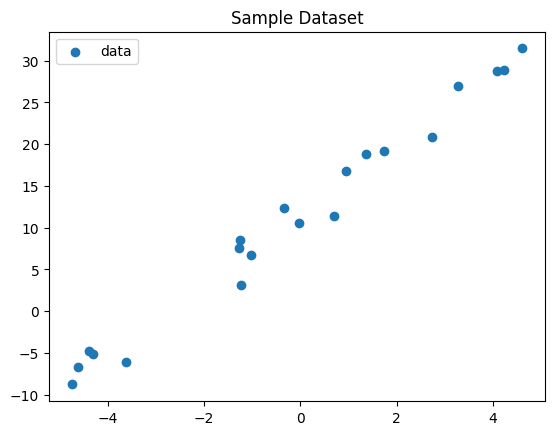

In [8]:
KEY, x_key, noise_key = random.split(KEY, num = 3)
n = 20
r = 7

x = random.uniform(x_key, shape = (n, ), minval = -5, maxval = 5)
y = 7 + 4 * x + r * random.uniform(noise_key, shape = (n, ))

plt.scatter(x, y, label = "data")
plt.title("Sample Dataset")
plt.legend()

## Prior

Let us use a zero-mean prior with RBF kernel in this experiment. 

In [9]:
def rbf_kernel(a, b, theta, ell):
    return theta**2 * jnp.exp(- 1/2 * jnp.sum(((a - b) / ell)**2, axis = -1))

prior = GaussianProcess(lambda x: jnp.zeros(x.shape[0]),
                        lambda a, b: rbf_kernel(a, b, theta = 10, ell = 1))

## Conditioning


In [10]:
def phi(x):
    return x.reshape(-1, 1)

posterior = prior.condition(y, phi(x), R = 5**2 * jnp.eye(x.shape[0]))

## Posterior Mean and Uncertainty


In [11]:
def plot_posterior_predictive(
    x_plot: jnp.ndarray,
    predictive_mean: jnp.ndarray, 
    predictive_variance: jnp.ndarray,
    data: tuple[jnp.ndarray, jnp.ndarray] | None = None,
    title: str | None = None,
    ax: Axes | None = None,
):
    if ax is None:
        ax = plt.gca()

    
    ax.plot(
        x_plot,
        predictive_mean,
        label=r"$\mu$",
    )

    ax.fill_between(
        x_plot,
        predictive_mean - jnp.sqrt(predictive_variance),
        predictive_mean + jnp.sqrt(predictive_variance),
        alpha=0.5,
        color="orange",
        label=r"$\mu \pm \sigma$",
    )

    ax.fill_between(
        x_plot,
        predictive_mean - 2 * jnp.sqrt(predictive_variance),
        predictive_mean + 2 * jnp.sqrt(predictive_variance),
        alpha=0.3,
        color="orange",
        label=r"$\mu \pm 2\sigma$",
    )

    if data is not None:
        x_data, y_data = data
        ax.scatter(x_data, y_data, label="Data", color = "green")

    if title is not None:
        ax.set_title(title)

    ax.legend()

    return ax

<Axes: title={'center': 'GP Regression'}>

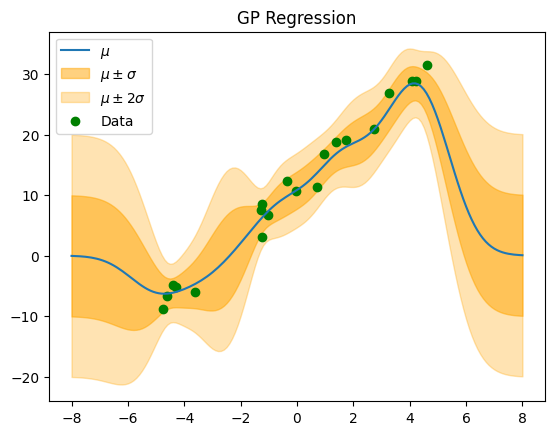

In [12]:
x_plot = jnp.arange(-8, 8.01, 0.1)
pred_mean = posterior._mean(phi(x_plot))
pred_var = posterior._covariance(phi(x_plot), phi(x_plot))

plot_posterior_predictive(x_plot, pred_mean, pred_var, data = (x, y), title = "GP Regression")

As can be seen, the mean of the posterior has captured the data trend on the used domain, but is still approaching the prior as we go further from the observed data points. It is the nature of the Gaussian Process conditioning, so do not get surprised. To tackle this kind of problem we can use different prior mean functions rather than using zero-mean as we did in our example.

The same effect applies to the latent covariance. We can see that far away from the observations we have around-constant latent marginal variance across the data points. This happens because the observations are poorly correlated with the points far away from them. That is why the quantity
$$ K_{*X} K_y^{-1} K_{X*} $$
is not large, thus, our latent uncertainty
$$ K_{**} - K_{*X} K_y^{-1} K_{X*} $$
does not change a lot with respect to the prior uncertainty $K_{**}$

## Posterior Samples


Since our posterior is a Gaussian Process and, when test samples are passed it is a Gaussian, we can sample from it. Let us try to sample from the posterior we have obtained.

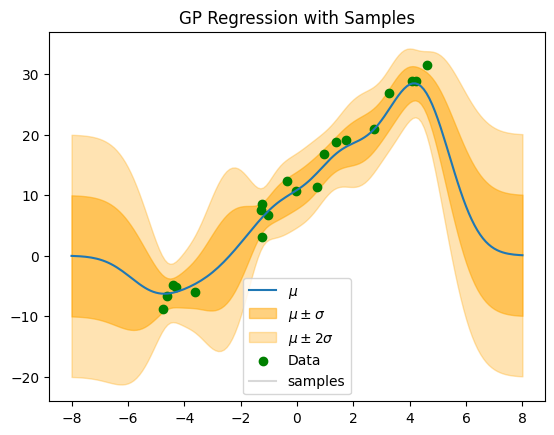

In [13]:
KEY, samples_key = random.split(KEY, num = 2)

samples = posterior(phi(x_plot)).sample(5, samples_key)

plot_posterior_predictive(x_plot, pred_mean, pred_var, data = (x, y), title = "GP Regression with Samples")

for i, sample in enumerate(samples):
    plt.plot(x_plot, sample, color = "gray", alpha = 0.3, label = "samples" if i == 0 else None)
plt.legend()


# Understanding Posterior Uncertainty


Now let us run some experiments that will help us understand the posterior uncertainty better

## Latent vs Predictive Uncertainty


As we have discussed, Latent and Predictive uncertainties differ in exclusion or inclusion of the future observation noise. Let us have a posterior
$$ f \mid X, y, X_* \sim \mathcal{N}(\mu_*, \Sigma_*) $$

then, our Latent Uncertainty **does not** include the future observations noise, and its diagonal entries are as follows:
$$ (\Sigma_*)_{ii} = \text{Var}(f(x_i^*) \mid X, y) $$
whereas the Predictive Uncertainty **does** include the observation noise, thus, a scalar is added to the variance:
$$ (\Sigma_*)_{ii} = \text{Var}(f(x_i^*) \mid X, y) + r^2 $$

where $r^2$ is the noise variance used in conditioning.

<Axes: title={'center': 'GP Regression Predictive'}>

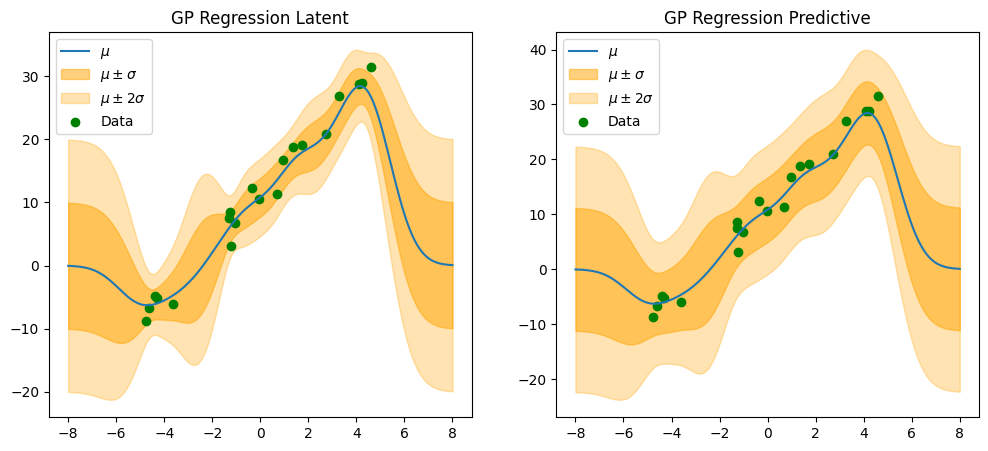

In [14]:
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (12, 5))

plot_posterior_predictive(x_plot, pred_mean, pred_var, data = (x, y), title = "GP Regression Latent", ax = axes[0])
plot_posterior_predictive(x_plot, pred_mean, pred_var + 5**2, data = (x, y), title = "GP Regression Predictive", ax = axes[1])

## Effect of Observation Noise


Now let us experiment on the Observation Noise. As we have discussed in the [./2. Bayesian Regression.ipynb](Bayesian Regression Notebook), the assumed noise of the made observations plays a huge role in the uncertainty estimation. If the "measurement tool" is very noisy, we should trust the obtained observations less, and vice versa. We have used standard deviation of the noise as $5$, let us also try several values that are smaller and larger than $5$

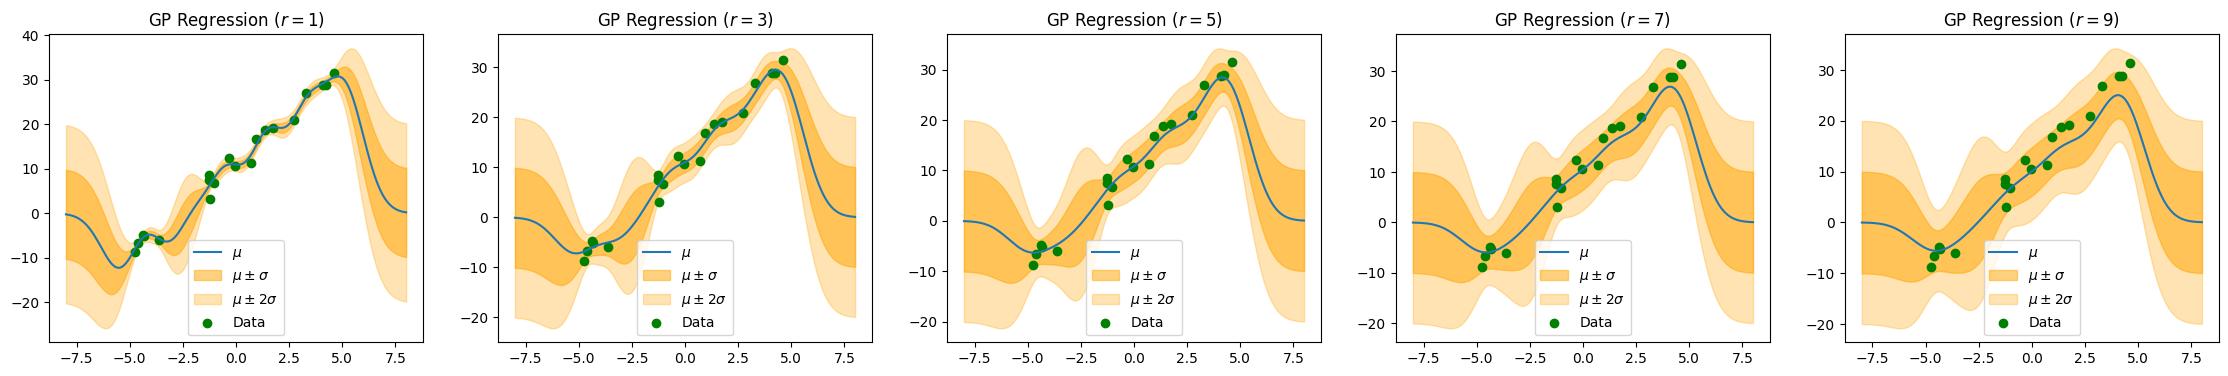

In [15]:
fig, axes = plt.subplots(nrows = 1, ncols = 5, figsize = (28, 4))

for i, r in enumerate([1, 3, 5, 7, 9]):
    posterior_i = prior.condition(y, phi(x), R = r**2 * jnp.eye(x.shape[0]))

    pred_mean = posterior_i._mean(phi(x_plot))
    pred_var = posterior_i._covariance(phi(x_plot), phi(x_plot))

    plot_posterior_predictive(x_plot, pred_mean, pred_var, data = (x, y), title = fr"GP Regression ($r = {r}$)", ax = axes[i])

As can be seen, the latent uncertainty is relatively small near the observations if the observation noise is small. It is as expected, since if the observations are less noisy, we should trust them more when the model is built, thus, the uncertainty will be less. Also, one can notice that the predictive mean is also acting similarly, trusting the observations more. One can associate this with the regularization in statistical linear regression.

## Effect of Data Density


Now let us see how the model behaves if the data is not as dense. For this experiment, let us erase all of the observations with $ x \in [-3, 3] $.

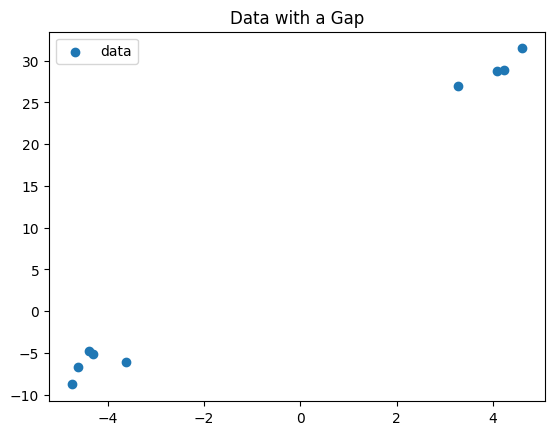

In [16]:
x_mask = (x < -3) | (x > 3)
x_gap = x[x_mask]
y_gap = y[x_mask]

plt.scatter(x_gap, y_gap, label = "data")
plt.title("Data with a Gap")
plt.legend()

<Axes: title={'center': 'Sparse Data GP Regression'}>

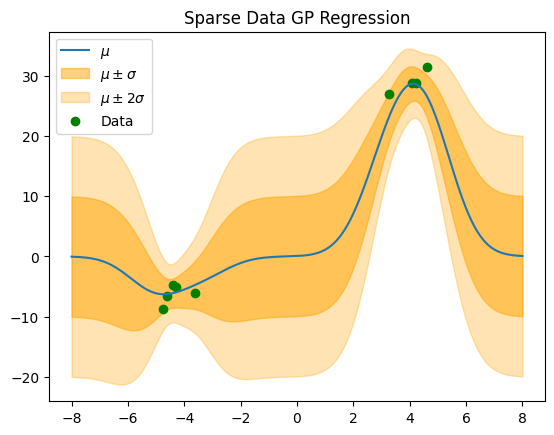

In [17]:
posterior_gap = prior.condition(y_gap, phi(x_gap), R = 5**2 * jnp.eye(x_gap.shape[0]))

pred_mean = posterior_gap._mean(phi(x_plot))
pred_var = posterior_gap._covariance(phi(x_plot), phi(x_plot))

plot_posterior_predictive(x_plot, pred_mean, pred_var, data = (x_gap, y_gap), title = "Sparse Data GP Regression")

From the plot of the latent distribution one can see that there the posterior mean and covariance are pretty much the same as the prior mean and covariance in the gap between the observations. Again, this can be seen from the formulae of the predictive mean and covariance, both are highly affected by the correlation between the observations and the test values. Since we did not have any observations in the region $x \in [-3, 3]$, the correlation between is very small, thus, less updated when the data is seen.


# Model Selection with Marginal Likelihood


## Marginal Likelihood


We know that
$$ y \sim \mathcal{N}(m_X, K_y) $$
thus, we can write the marginal log-likelihood as
$$ \log p(y \mid X, \theta) = -\frac{1}{2} (y - m_X)^T K_y^{-1} (y - m_X) - \frac{1}{2} \log |K_y| - \frac{n}{2} \log (2 \pi) $$
where $\theta$ is the set of model hyperparameters such as length scale, kernel amplitude, observation noise, etc.

We can call a Gaussian Process on some set of points and obtain a Multivariate Gaussian, thus, can easily compute the log-likelihood using the `Gaussian.log_pdf` function.

## Interpretation


Let us consider a simple 1D example:
$$ y \mid x \sim \mathcal{N}(m(x), s^2) $$
then we want both $m(x) \approx y$ and $s^2$ not to be very large. The first condition is pretty intuitive: we want our model to be very close, on average, to the observed information. The second condition can be understood as follows:

* large $s$ will make many values of $y$ not very surprising with respect to $m(x)$, but it will spread the probability density over a wide range
* small $s$ will mean that any observation not near $m(x)$ is practically impossible

So, the desired model should somehow balance the accuracy of the model prediction and the probability density assigned to the particular observations.

The formula of the marginal log-likelihood can be interpreted as:
$$ \log p(y \mid X, \theta) = \underbrace{-\frac{1}{2} (y - m_X)^T K_y^{-1} (y - m_X)}_{\text{model fit}} + \underbrace{-\frac{1}{2} \log |K_y|}_{\text{complexity}} + \underbrace{-\frac{n}{2} \log (2 \pi)}_{\text{const.}} $$

Here:

* **Model Fit** tells us how close the model's mean is to the observed values of $y$. 
* **Complexity** tells us how the total probability is assigned in this covariance model.
* **Constant** is normalization term to obtain a valid probability density.

Suppose one model assigns high probability density to a small set of possible observations and another model assigns reasonable probability density to a wide range of observations. Then, the complexity penalty is larger for the second model, so the marginal log-likelihood penalizes it for spreading probability density too broadly.

So, generally, marginal likelihood balances model fitting and assigning probability density to the observed data.

## Hyperparameter Comparison


Let us try to find the best suited model (in terms of hyperparameter choice) for the regression problem we have defined above with the same zero-mean and rbf kernel model. We will calculate the marginal log-likelihood of each of the models and compare them.

The noise standard deviation will be used as $5$ as before and the marginal log-likelihood will be evaluated on the training sample.

In [18]:
theta_arr = [0.1, 0.5, 1, 2, 5, 10, 15, 20]
ell_arr = [0.1, 0.5, 1, 2, 5, 10, 15, 20]

marginal_log_likelihood = [[0.0 for _ in ell_arr] for _ in theta_arr]

for i, theta in enumerate(theta_arr):
    for j, ell in enumerate(ell_arr):
        prior_i = GaussianProcess(lambda x: jnp.zeros(x.shape[0]), 
                                  lambda a, b, theta = theta, ell = ell: rbf_kernel(a, b, theta = theta, ell = ell))

        latent_prior = prior_i(phi(x))

        observation_prior = Gaussian(
            mu = latent_prior.mu,
            Sigma = latent_prior.Sigma + 5**2 * jnp.eye(x.shape[0]),
        )

        mll = observation_prior.log_pdf(y)


        marginal_log_likelihood[i][j] = mll
        

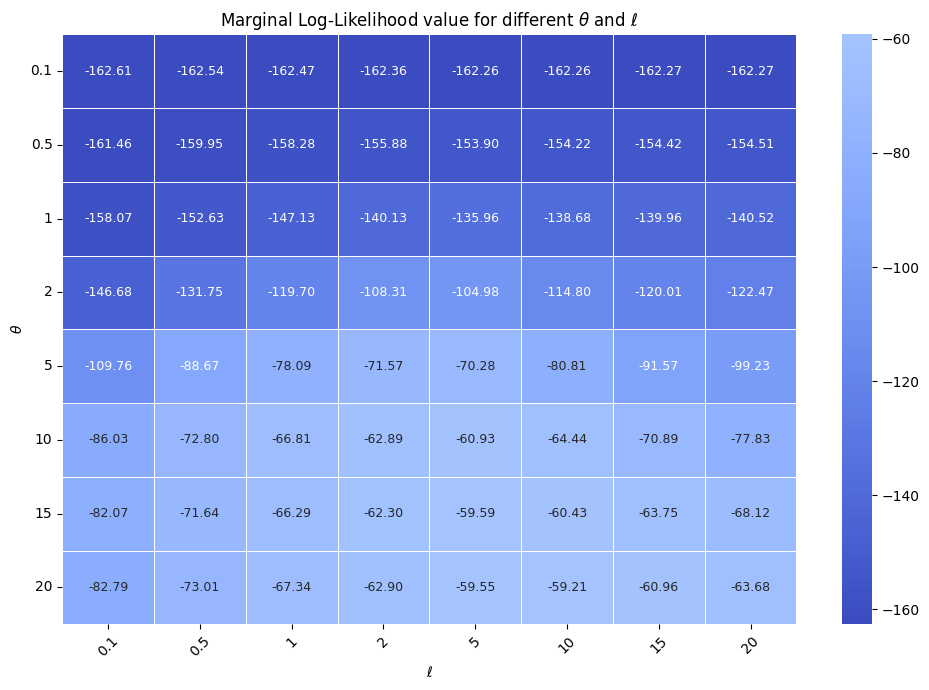

In [19]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))

sns.heatmap(
    jnp.asarray(marginal_log_likelihood),
    ax=ax,
    annot=True,
    fmt=".2f",
    annot_kws={"fontsize": 9},
    xticklabels=[f"{x:.3g}" for x in ell_arr],
    yticklabels=[f"{x:.3g}" for x in theta_arr],
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$\theta$")
ax.set_title(r"Marginal Log-Likelihood value for different $\theta$ and $\ell$")

ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

Since greater marginal log-likelihood implies better fit of the observations given the model, we can conclude that RBF kernel with $\theta = 15$ and $\ell = 5$ is the best model we have assessed in this experiment. Let us see the graph of the obtained prior

<Axes: title={'center': '$\\theta = 15, \\ell = 5$ Posterior'}>

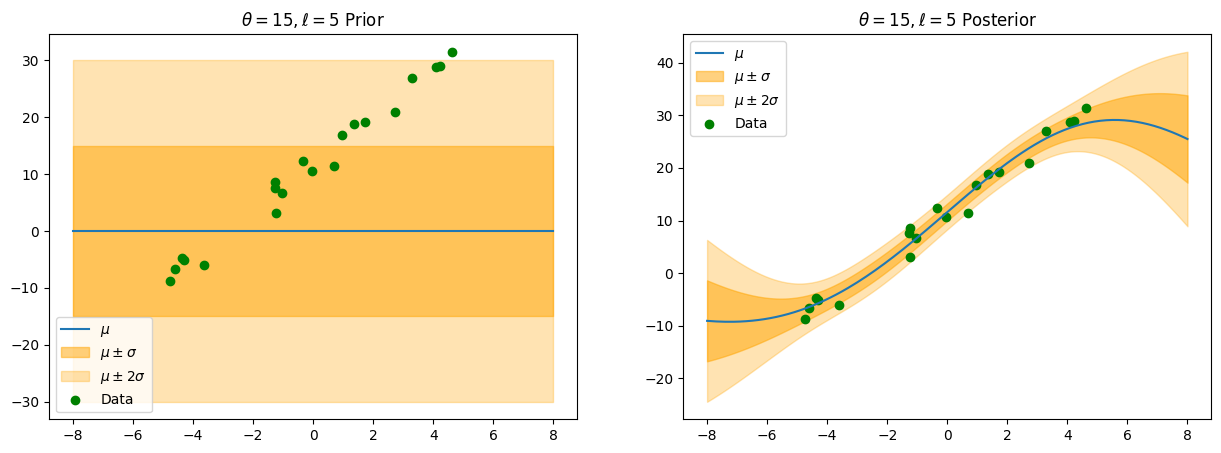

In [20]:
prior = GaussianProcess(lambda x: jnp.zeros(x.shape[0]), 
                        lambda a, b: rbf_kernel(a, b, theta = 15, ell = 5))

pred_mean_prior = prior(phi(x_plot)).mu
pred_var_prior = jnp.diag(prior(phi(x_plot)).Sigma)

posterior = prior.condition(y, phi(x), 5**2 * jnp.eye(x.shape[0]))

pred_mean_post = posterior._mean(phi(x_plot))
pred_var_post = posterior._covariance(phi(x_plot), phi(x_plot))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_plot, pred_mean_prior, pred_var_prior, (x, y), title = r"$\theta = 15, \ell = 5$ Prior", ax = axes[0])
plot_posterior_predictive(x_plot, pred_mean_post, pred_var_post, (x, y), title = r"$\theta = 15, \ell = 5$ Posterior", ax = axes[1])

<Axes: title={'center': '$\\theta = 0.1, \\ell = 5$ Posterior'}>

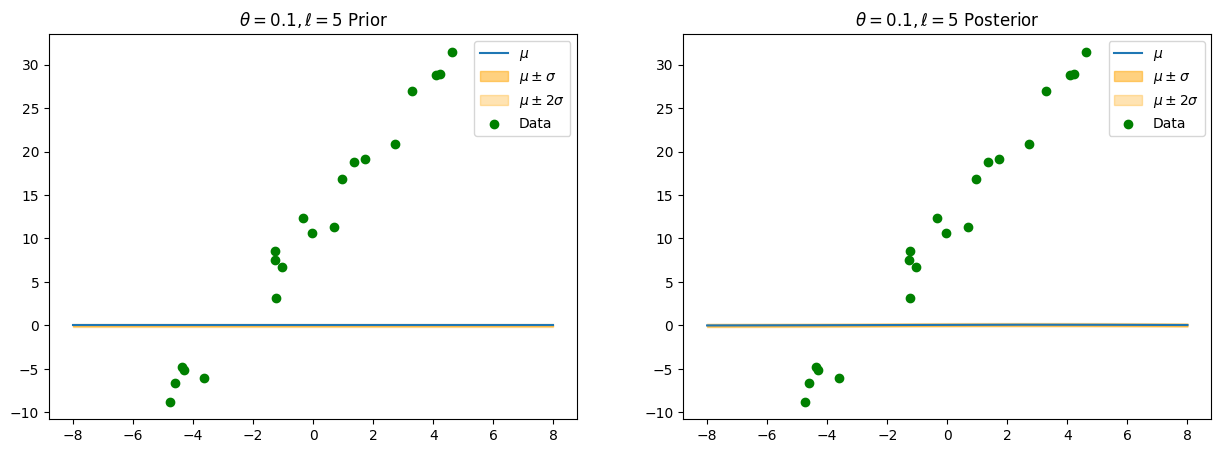

In [21]:
prior = GaussianProcess(lambda x: jnp.zeros(x.shape[0]), 
                        lambda a, b: rbf_kernel(a, b, theta = 0.1, ell = 5))

pred_mean_prior = prior(phi(x_plot)).mu
pred_var_prior = jnp.diag(prior(phi(x_plot)).Sigma)

posterior = prior.condition(y, phi(x), 5**2 * jnp.eye(x.shape[0]))

pred_mean_post = posterior._mean(phi(x_plot))
pred_var_post = posterior._covariance(phi(x_plot), phi(x_plot))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_plot, pred_mean_prior, pred_var_prior, (x, y), title = r"$\theta = 0.1, \ell = 5$ Prior", ax = axes[0])
plot_posterior_predictive(x_plot, pred_mean_post, pred_var_post, (x, y), title = r"$\theta = 0.1, \ell = 5$ Posterior", ax = axes[1])

## Hyperparameter Optimization


The negative marginal log-likelihood is differentiable with respect to the hyperparameters, but it is generally non-convex. Gradient-based optimization may therefore converge to different local optimum depending on initialization. Let us use the basic gradient descent with `jax.grad` to calculate the gradient of the objective function with respect to the hyperparameters. We will optimize the values of $\theta$, $\ell$, and noise standard deviation $\sigma$.

Since we want to run unconstrained optimization but our parameters must be positive, we optimize their logarithms. This will allow us to ignore the positivity constraint.

Final Theta: 31.6705241704789
Final Ell: 12.513435865370681
Final Noise Std: 1.8212793437851298


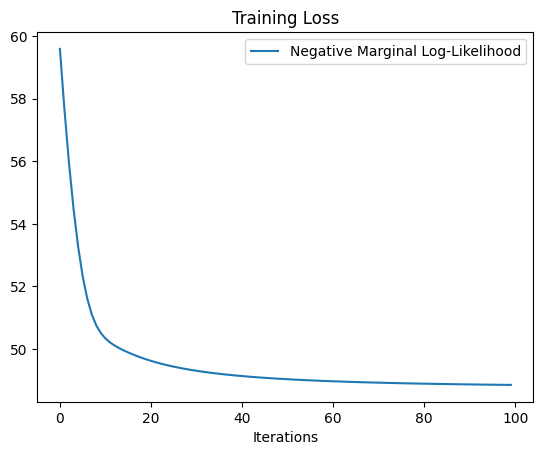

In [22]:
def negative_marginal_log_likelihood(x: jnp.ndarray, 
                                     y: jnp.ndarray,
                                     log_theta: float, 
                                     log_ell: float, 
                                     log_noise_std: float) -> float:
    theta = jnp.exp(log_theta)
    ell = jnp.exp(log_ell)
    noise_std = jnp.exp(log_noise_std)

    m = jnp.zeros(x.shape[0])
    K = rbf_kernel(phi(x)[:, None, :], phi(x)[None, :, :], theta = theta, ell = ell) + (noise_std**2 + 1e-6) * jnp.eye(x.shape[0])
    L = jax.scipy.linalg.cho_factor(K, lower = True)

    model_fit = 1/2 * (y - m).T @ jax.scipy.linalg.cho_solve(L, y - m)
    complexity = jnp.sum(jnp.log(jnp.diag(L[0])))
    normalization = 1/2 * x.shape[0] * jnp.log(2 * jnp.pi)

    return model_fit + complexity + normalization

learning_rate = 0.01

log_theta = jnp.log(15.0)
log_ell = jnp.log(5.0)
log_noise_std = jnp.log(5.0)

n_iter = 100
training_loss = []

for i in range(n_iter):
    loss = negative_marginal_log_likelihood(x, y, log_theta, log_ell, log_noise_std)
    training_loss.append(loss)

    grad_log_theta, grad_log_ell, grad_log_noise_std = jax.grad(negative_marginal_log_likelihood, argnums = (2, 3, 4))(x, y, log_theta, log_ell, log_noise_std)

    log_theta -= learning_rate * grad_log_theta
    log_ell -= learning_rate * grad_log_ell
    log_noise_std -= learning_rate * grad_log_noise_std

theta = jnp.exp(log_theta)
ell = jnp.exp(log_ell)
noise_std = jnp.exp(log_noise_std)

plt.plot(training_loss, label = "Negative Marginal Log-Likelihood")
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.legend()

print("Final Theta:", theta)
print("Final Ell:", ell)
print("Final Noise Std:", noise_std)

<Axes: title={'center': 'Posterior with Optimal Hyperparameters'}>

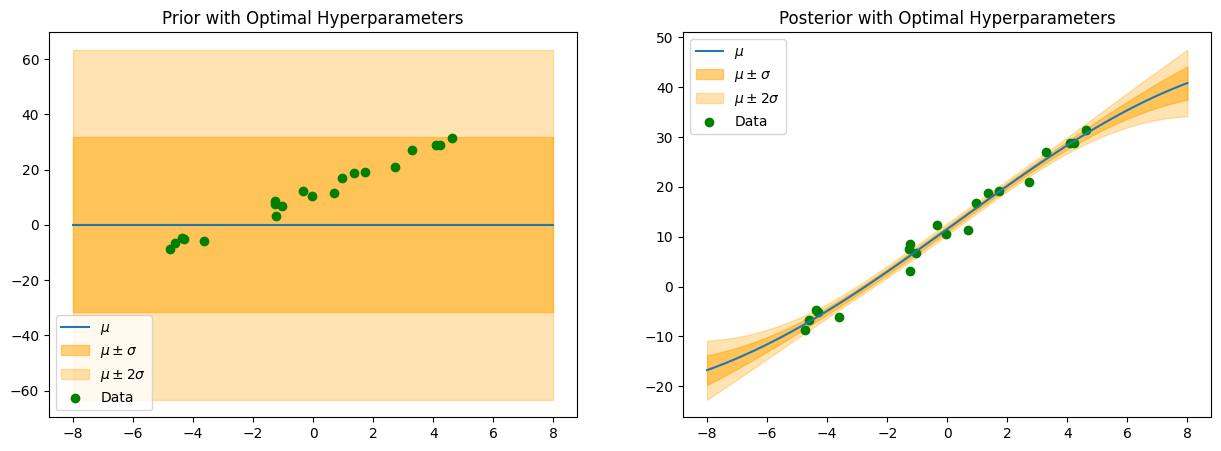

In [23]:
prior = GaussianProcess(lambda x: jnp.zeros(x.shape[0]), 
                        lambda a, b: rbf_kernel(a, b, theta = theta, ell = ell))

pred_mean_prior = prior(phi(x_plot)).mu
pred_var_prior = jnp.diag(prior(phi(x_plot)).Sigma)

posterior = prior.condition(y, phi(x), noise_std**2 * jnp.eye(x.shape[0]))

pred_mean_post = posterior._mean(phi(x_plot))
pred_var_post = posterior._covariance(phi(x_plot), phi(x_plot))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_plot, pred_mean_prior, pred_var_prior, (x, y), title = r"Prior with Optimal Hyperparameters", ax = axes[0])
plot_posterior_predictive(x_plot, pred_mean_post, pred_var_post, (x, y), title = r"Posterior with Optimal Hyperparameters", ax = axes[1])

That is how we can initialize the prior Gaussian Process without blindly picking the hyperparameters. In the experiment above we have used zero mean function. One can also use linear mean function and run the optimization procedure on the slope and intercept as hyperparameters as well.

Note that the optimization process might converge to a local optimum, this problem can be tackled to some extent using momentum-based algorithms.

# Real Dataset Example


Now let us consider a real-life dataset. Mauna Loa monthly atmospheric $\text{CO}_{\text{2}}$ dataset will be used since it is periodic with a general trend, which suits the Gaussian Processes well. Also it is a time-series data, so we can visualize it nicely.

## Data and Preprocessing


In [24]:
import pandas as pd

url = (
    "https://gml.noaa.gov/webdata/ccgg/"
    "trends/co2/co2_mm_mlo.csv"
)

co2 = pd.read_csv(
    url,
    comment="#",
)

co2.columns = (
    co2.columns
    .str.strip()
    .str.lower()
)

co2

,year,month,decimal date,average,deseasonalized,ndays,sdev,unc
0,1958,3,1958.2027,315.71,314.44,-1,-9.99,-0.99
1,1958,4,1958.2877,317.45,315.16,-1,-9.99,-0.99
2,1958,5,1958.3699,317.51,314.69,-1,-9.99,-0.99
3,1958,6,1958.4548,317.27,315.15,-1,-9.99,-0.99
4,1958,7,1958.5370,315.87,315.20,-1,-9.99,-0.99
...,...,...,...,...,...,...,...,...
817,2026,4,2026.2917,431.12,428.61,23,1.16,0.46
818,2026,5,2026.3750,432.34,429.06,19,0.64,0.28
819,2026,6,2026.4583,431.43,428.99,19,0.27,0.12
820,2026,7,2026.5417,429.13,428.78,21,0.61,0.26


Let us assume that the measurements were made on the first day of each month and model the average atmospheric carbon dioxide concentration.

In [25]:
co2["date"] = pd.to_datetime(co2["year"].astype(str) + "-" + co2["month"].astype(str) + "-01")
co2["co2"] = co2["average"]

co2 = co2[["date", "co2"]].sort_values("date").reset_index(drop = True)

co2

,date,co2
0,1958-03-01,315.71
1,1958-04-01,317.45
2,1958-05-01,317.51
3,1958-06-01,317.27
4,1958-07-01,315.87
...,...,...
817,2026-04-01,431.12
818,2026-05-01,432.34
819,2026-06-01,431.43
820,2026-07-01,429.13


Using covariance matrix of size $820 \times 820$ would be a bit too expensive computationally given that we will also optimize the negative marginal log-likelihood, so let us use only data starting in 2000.

Text(0, 0.5, 'CO2 Concentration (ppm)')

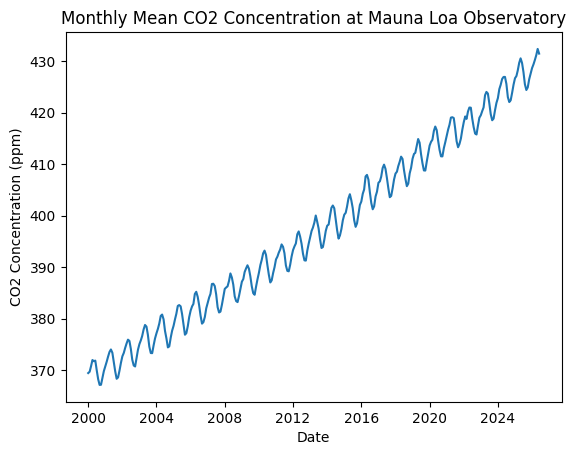

In [26]:
co2 = co2[(co2["date"] >= "2000-01-01") & (co2["date"] <= "2026-06-01")].reset_index(drop = True)

plt.plot(co2["date"], co2["co2"])
plt.title("Monthly Mean CO2 Concentration at Mauna Loa Observatory")
plt.xlabel("Date")
plt.ylabel("CO2 Concentration (ppm)")

If we zoom in we can see the pattern. Let us consider a five-year period.

Text(0, 0.5, 'CO2 Concentration (ppm)')

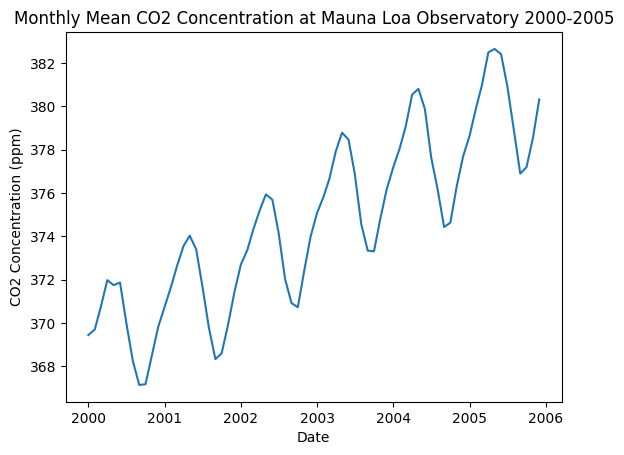

In [27]:
co2_2000 = co2[(co2["date"] >= "2000-01-01") & (co2["date"] <= "2005-12-31")]

plt.plot(co2_2000["date"], co2_2000["co2"])
plt.title("Monthly Mean CO2 Concentration at Mauna Loa Observatory 2000-2005")
plt.xlabel("Date")
plt.ylabel("CO2 Concentration (ppm)")

Let us use data starting from 2020 as test data, convert dates into scalars and standardize the target

Text(0.5, 1.0, 'Standardized CO2 Data')

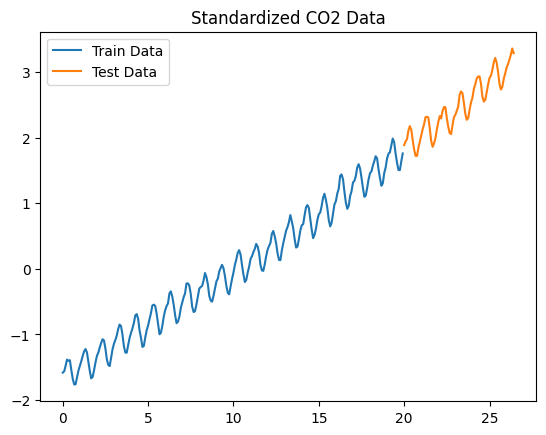

In [28]:
train_co2 = co2[co2["date"] < "2020-01-01"]
test_co2 = co2[co2["date"] >= "2020-01-01"]

def date_to_num(date):
    return (date - pd.Timestamp("2000-01-01")).days / 365.25

x_train = train_co2["date"].apply(date_to_num).values
x_test = test_co2["date"].apply(date_to_num).values

y_train = train_co2["co2"].values
y_test = test_co2["co2"].values

y_mean = jnp.mean(y_train)
y_std = jnp.std(y_train)

y_train = (y_train - y_mean) / y_std
y_test = (y_test - y_mean) / y_std

plt.plot(x_train, y_train, label = "Train Data")
plt.plot(x_test, y_test, label = "Test Data")
plt.legend()
plt.title("Standardized CO2 Data")

## Model Design


There is a general increasing trend in the data, so let us use a linear mean function. Since the data is also periodic and has local deviations, let us use a composite kernel:
$$ k(x, x') = k_{\text{trend}}(x, x') + k_{\text{periodic}}(x, x') + k_{\text{local}}(x, x') $$

with:

* RBF general trend kernel
$$ k_{\text{trend}}(x, x') = \theta_{\text{trend}}^2 \exp \left( -\frac{(x - x')^2}{2 \ell_{\text{trend}}^2} \right) $$
* Exponential Sine-Squared periodic kernel
$$ k_{\text{periodic}}(x, x') = \theta_{\text{periodic}}^2 \exp \left( -\frac{2 \sin^2(\pi |x - x'| / p)}{\ell_{\text{periodic}}^2} \right) $$
with a period $p = 1$ year
* Matern local kernel
$$ k_{\text{local}}(x, x') = \theta_{\text{local}}^2 \left( 1 + \frac{\sqrt{3} |x - x'| }{\ell_{\text{local}}} \right) \exp \left( -\frac{\sqrt{3} | x - x' |}{\ell_{\text{local}}} \right) $$

In [29]:
def phi(x):
    return x.reshape(-1, 1)

def linear_mean(x: jnp.ndarray, a: float, b: float) -> jnp.ndarray:
    return (a * x + b).reshape(-1)

def sin_kernel(a: jnp.ndarray, b: jnp.ndarray, theta: float, ell: float) -> jnp.ndarray:
    norm = jnp.linalg.norm(a-b, 2, axis = -1)
    return theta**2 * jnp.exp(-2 * jnp.sin(jnp.pi * norm)**2 / ell**2)

def matern_kernel(a: jnp.ndarray, b: jnp.ndarray, theta: float, ell: float) -> jnp.ndarray:
    norm = jnp.linalg.norm(a-b, 2, axis = -1)
    return theta**2 * (1 + jnp.sqrt(3) * norm / ell) * jnp.exp(-jnp.sqrt(3) * norm / ell)

def composite_kernel(a: jnp.ndarray, 
                     b: jnp.ndarray, 
                     theta_trend: float,
                     ell_trend: float,
                     theta_periodic: float,
                     ell_periodic: float,
                     theta_local: float,
                     ell_local: float) -> jnp.ndarray:
    return (rbf_kernel(a, b, theta = theta_trend, ell = ell_trend) +
            sin_kernel(a, b, theta = theta_periodic, ell = ell_periodic) +
            matern_kernel(a, b, theta = theta_local, ell = ell_local))

In [30]:
def negative_marginal_log_likelihood(x: jnp.ndarray, 
                                     y: jnp.ndarray,
                                     slope: float,
                                     intercept: float,
                                     log_theta_trend: float,
                                     log_ell_trend: float,
                                     log_theta_periodic: float,
                                     log_ell_periodic: float,
                                     log_theta_local: float,
                                     log_ell_local: float,
                                     log_noise_std: float) -> float:
    
    theta_trend = jnp.exp(log_theta_trend)
    ell_trend = jnp.exp(log_ell_trend)
    theta_periodic = jnp.exp(log_theta_periodic)
    ell_periodic = jnp.exp(log_ell_periodic)
    theta_local = jnp.exp(log_theta_local)
    ell_local = jnp.exp(log_ell_local)
    noise_std = jnp.exp(log_noise_std)

    m = linear_mean(x, slope, intercept)
    K = composite_kernel(phi(x)[:, None, :], 
                         phi(x)[None, :, :], 
                         theta_trend = theta_trend, ell_trend = ell_trend,
                         theta_periodic = theta_periodic, ell_periodic = ell_periodic,
                         theta_local = theta_local, ell_local = ell_local) + (noise_std**2 + 1e-6) * jnp.eye(x.shape[0])
    L = jax.scipy.linalg.cho_factor(K, lower = True)

    model_fit = 1/2 * (y - m).T @ jax.scipy.linalg.cho_solve(L, y - m)
    complexity = jnp.sum(jnp.log(jnp.diag(L[0])))
    normalization = 1/2 * x.shape[0] * jnp.log(2 * jnp.pi)

    return model_fit + complexity + normalization

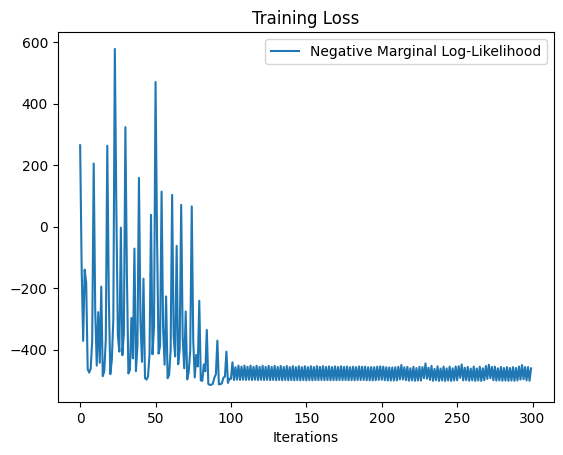

In [31]:
slope = 0.0
intercept = 0.0

log_theta_trend = 0.0
log_ell_trend = 0.0

log_theta_periodic = 0.0
log_ell_periodic = 0.0

log_theta_local = 0.0
log_ell_local = 0.0

log_noise_std = 0.0

n_iter = 300
training_loss = []

best_loss = float("inf")
best_slope = 0.0
best_intercept = 0.0
best_log_theta_trend = 0.0
best_log_ell_trend = 0.0
best_log_theta_periodic = 0.0
best_log_ell_periodic = 0.0
best_log_theta_local = 0.0
best_log_ell_local = 0.0
best_log_noise_std = 0.0

learning_rate = 0.01

for i in range(n_iter):
    loss = negative_marginal_log_likelihood(x_train, y_train, slope, intercept,
                                            log_theta_trend, log_ell_trend,
                                            log_theta_periodic, log_ell_periodic,
                                            log_theta_local, log_ell_local,
                                            log_noise_std)
    training_loss.append(loss)

    if loss < best_loss:
        best_loss = loss
        best_slope = slope
        best_intercept = intercept
        best_log_theta_trend = log_theta_trend
        best_log_ell_trend = log_ell_trend
        best_log_theta_periodic = log_theta_periodic
        best_log_ell_periodic = log_ell_periodic
        best_log_theta_local = log_theta_local
        best_log_ell_local = log_ell_local
        best_log_noise_std = log_noise_std

    grads = jax.grad(negative_marginal_log_likelihood, 
                     argnums = (2, 3, 4, 5, 6, 7, 8, 9, 10))(x_train, y_train,
                                                             slope, intercept,
                                                             log_theta_trend, log_ell_trend,
                                                             log_theta_periodic, log_ell_periodic,
                                                             log_theta_local, log_ell_local,
                                                             log_noise_std)

    slope -= learning_rate * grads[0]
    intercept -= learning_rate * grads[1]
    log_theta_trend -= learning_rate * grads[2]
    log_ell_trend -= learning_rate * grads[3]
    log_theta_periodic -= learning_rate * grads[4]
    log_ell_periodic -= learning_rate * grads[5]
    log_theta_local -= learning_rate * grads[6]
    log_ell_local -= learning_rate * grads[7]
    log_noise_std -= learning_rate * grads[8]

slope = best_slope
intercept = best_intercept
theta_trend = jnp.exp(best_log_theta_trend)
ell_trend = jnp.exp(best_log_ell_trend)
theta_periodic = jnp.exp(best_log_theta_periodic)
ell_periodic = jnp.exp(best_log_ell_periodic)
theta_local = jnp.exp(best_log_theta_local)
ell_local = jnp.exp(best_log_ell_local)
noise_std = jnp.exp(best_log_noise_std)

plt.plot(training_loss, label = "Negative Marginal Log-Likelihood")
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.legend()

In [32]:
prior = GaussianProcess(lambda x: linear_mean(x, slope, intercept), 
                        lambda a, b: composite_kernel(a, b, 
                                                      theta_trend = theta_trend, ell_trend = ell_trend,
                                                      theta_periodic = theta_periodic, ell_periodic = ell_periodic,
                                                      theta_local = theta_local, ell_local = ell_local))

## Prediction


<Axes: title={'center': 'Posterior with Optimal Hyperparameters'}>

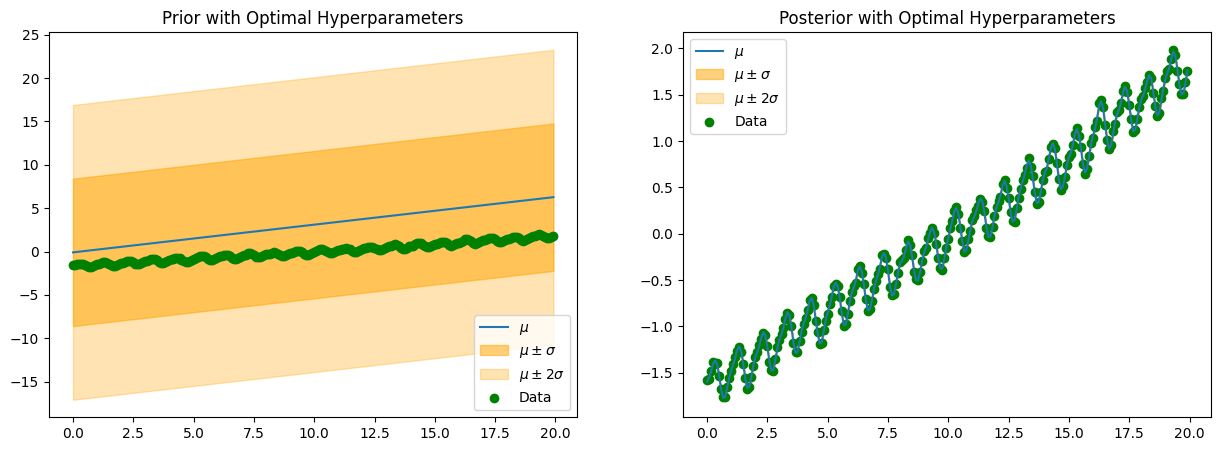

In [33]:
posterior = prior.condition(y_train, phi(x_train), noise_std**2 * jnp.eye(x_train.shape[0]))

pred_mean_prior = prior(phi(x_train)).mu
pred_var_prior = jnp.diag(prior(phi(x_train)).Sigma)

pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_train, pred_mean_prior, pred_var_prior, (x_train, y_train), title = r"Prior with Optimal Hyperparameters", ax = axes[0])
plot_posterior_predictive(x_train, pred_mean_post, pred_var_post, (x_train, y_train), title = r"Posterior with Optimal Hyperparameters", ax = axes[1])

Text(0.5, 1.0, 'GP Regression on Train, Test, and Future Data')

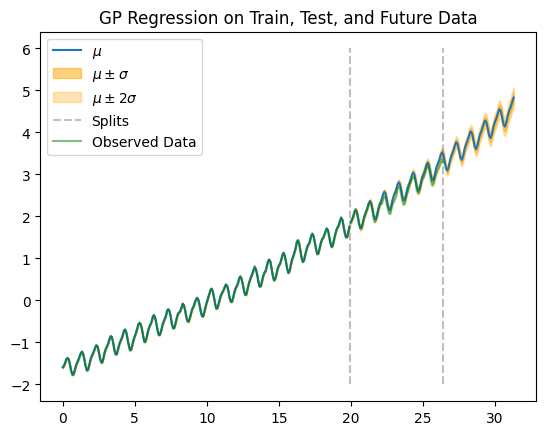

In [34]:
x_plot = jnp.arange(max(x_test), max(x_test) + 5, 0.1)

pred_mean_train = posterior._mean(phi(x_train))
pred_var_train = posterior._covariance(phi(x_train), phi(x_train))

pred_mean_test = posterior._mean(phi(x_test))
pred_var_test = posterior._covariance(phi(x_test), phi(x_test))

pred_mean_plot = posterior._mean(phi(x_plot))
pred_var_plot = posterior._covariance(phi(x_plot), phi(x_plot))

plt.plot(x_train, pred_mean_train, label = r"$\mu$", color = "tab:blue")
plt.fill_between(x_train, 
                pred_mean_train - jnp.sqrt(pred_var_train), 
                pred_mean_train + jnp.sqrt(pred_var_train),
                alpha=0.5,
                color="orange",
                label=r"$\mu \pm \sigma$")

plt.fill_between(x_train, 
                pred_mean_train - 2 * jnp.sqrt(pred_var_train), 
                pred_mean_train + 2 * jnp.sqrt(pred_var_train),
                alpha=0.3,
                color="orange",
                label=r"$\mu \pm 2\sigma$")

plt.vlines(x_train[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", label = "Splits", alpha = 0.5)

plt.plot(x_test, pred_mean_test, color = "tab:blue")
plt.fill_between(x_test, 
                pred_mean_test - jnp.sqrt(pred_var_test), 
                pred_mean_test + jnp.sqrt(pred_var_test),
                alpha=0.5,
                color="orange")

plt.fill_between(x_test, 
                pred_mean_test - 2 * jnp.sqrt(pred_var_test), 
                pred_mean_test + 2 * jnp.sqrt(pred_var_test),
                alpha=0.3,
                color="orange")

plt.vlines(x_test[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", alpha = 0.5)

plt.plot(x_plot, pred_mean_plot, color = "tab:blue")
plt.fill_between(x_plot, 
                pred_mean_plot - jnp.sqrt(pred_var_plot), 
                pred_mean_plot + jnp.sqrt(pred_var_plot),
                alpha=0.5,
                color="orange")

plt.plot(x_train, y_train, color = "green", label = "Observed Data", alpha = 0.5)
plt.plot(x_test, y_test, color = "green", alpha = 0.5)

plt.fill_between(x_plot, 
                pred_mean_plot - 2 * jnp.sqrt(pred_var_plot), 
                pred_mean_plot + 2 * jnp.sqrt(pred_var_plot),
                alpha=0.3,
                color="orange")

plt.legend()
plt.title("GP Regression on Train, Test, and Future Data")

## Evaluation


Now let us evaluate our model on our hold-out set. Here we will use not latent variance as we have used in all of our plots, but predictive variance, meaning that we will encounter for the future measurement noise as well. Formally:
$$ y_i \mid X, y, x_i \sim \mathcal{N}(\mu_i, v_i) $$
where
$$ v_i = \text{Var}(f_i \mid y) + \sigma^2 $$

The model will be evaluated using the following metrics:

* $R^2$ with respect to point predictions:
$$ R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \mu_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2} $$
* Root Mean-Square Error (RMSE) with respect to point predictions:
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \mu_i)^2} $$
* Negative Log-Predictive Density:
$$ \text{NLPD} = \frac{1}{n} \sum_{i=1}^n \left[ \frac{1}{2} \log(2 \pi v_i) + \frac{(y_i - \mu_i)^2}{2v_i} \right] $$
* Predictive Interval Coverage:
$$ I_i^{0.95} = \left[ \mu_i - 1.96 \sqrt{v_i}, \mu_i + 1.96 \sqrt{v_i} \right] $$
$$ \text{Coverage}_{95} = \frac{1}{n} \sum_{i=1}^n \mathbf{1}_{y_i \in I_i} $$
* Mean Interval Width:
$$ \text{Width}_{95} = \frac{1}{n} \sum_{i=1}^n 2(1.96)\sqrt{v_i} $$

$R^2$ and RMSE will tell us how precisely our model predicts the points (mean values). NLPD penalizes both uncertain and inaccurate models by encountering both point prediction and predictive variance. Coverage tells us how "unsurprising" are our observations with respect to point predictions and variance, however, if a model estimates the variance as something very large, coverage will be close to 1, but we cant claim that the model is doing great. That is why we also use Mean Interval Width, basically telling how wide are the "unsurprising" intervals on average.

In [35]:
def r2_score(y: jnp.ndarray, mu: jnp.ndarray) -> float:
    return 1 - jnp.sum((y - mu)**2) / jnp.sum((y - jnp.mean(y))**2)

def rmse(y: jnp.ndarray, mu: jnp.ndarray) -> float:
    return jnp.sqrt(jnp.mean((y - mu)**2))

def nlpd(y: jnp.ndarray, mu: jnp.ndarray, var: jnp.ndarray) -> float:
    return jnp.mean(1/2 * jnp.log(2 * jnp.pi * var) + (y - mu)**2 / (2 * var))

def coverage(y: jnp.ndarray, mu: jnp.ndarray, var: jnp.ndarray, alpha: float = 0.95) -> float:
    z = jax.scipy.stats.norm.ppf(1 - (1 - alpha) / 2)
    lower_bound = mu - z * jnp.sqrt(var)
    upper_bound = mu + z * jnp.sqrt(var)
    return jnp.mean((y >= lower_bound) & (y <= upper_bound))

def mean_interval_width(var: jnp.ndarray, alpha: float = 0.95) -> float:
    z = jax.scipy.stats.norm.ppf(1 - (1 - alpha) / 2)
    return jnp.mean(2 * z * jnp.sqrt(var))

def evaluate_model(y: jnp.ndarray, mu: jnp.ndarray, var: jnp.ndarray, alpha: float = 0.95) -> dict:
    return {
        "R2": r2_score(y, mu),
        "RMSE": rmse(y, mu),
        "NLPD": nlpd(y, mu, var),
        "Coverage": coverage(y, mu, var, alpha),
        "Mean Interval Width": mean_interval_width(var, alpha)
    }

In [36]:
pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train)) + noise_std**2

train_metrics = evaluate_model(y_train, pred_mean_post, pred_var_post)

print("Train Data:")
for i in train_metrics:
    print(f"{i}: {train_metrics[i]:.4f}")

Train Data:
R2: 0.9999
RMSE: 0.0117
NLPD: -2.9051
Coverage: 0.9917
Mean Interval Width: 0.0684


In [37]:
pred_mean_post = posterior._mean(phi(x_test))
pred_var_post = posterior._covariance(phi(x_test), phi(x_test)) + noise_std**2

test_metrics = evaluate_model(y_test, pred_mean_post, pred_var_post)

print("Test Data:")
for i in test_metrics:
    print(f"{i}: {test_metrics[i]:.4f}")

Test Data:
R2: 0.9488
RMSE: 0.0965
NLPD: -0.1578
Coverage: 0.5769
Mean Interval Width: 0.1747


### Coverage and Width at Several Nominal Levels

Theoretically, for a nominal predictive coverage $\alpha$, the rate of the data points lying in the interval should approximately equal $\alpha$. We have tested the coverage for $\alpha = 0.95$ and obtained results of perfect coverage, meaning that all of the data points happened to lay inside the interval $\left[ \mu_i - 1.96 \sqrt{v_i}, \mu_i + 1.96 \sqrt{v_i} \right]$. We might be lucky to see such results, so let us check similar thing for different confidence levels.

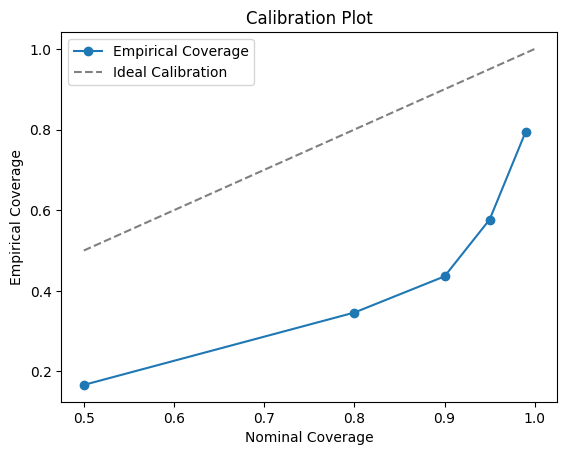

In [38]:
levels = [0.50, 0.80, 0.90, 0.95, 0.99]

calibration_results = []

for level in levels:
    empirical_coverage = coverage(
        y_test,
        pred_mean_post,
        pred_var_post,
        alpha=level,
    )

    interval_width = mean_interval_width(
        pred_var_post,
        alpha=level,
    )

    calibration_results.append({
        "Nominal": level,
        "Empirical": float(empirical_coverage),
        "Mean width": float(interval_width),
    })

plt.plot([res["Nominal"] for res in calibration_results],
         [res["Empirical"] for res in calibration_results],
         marker="o", label="Empirical Coverage")

plt.plot([0.5, 1], [0.5, 1], linestyle="--", color="gray", label="Ideal Calibration")
plt.title("Calibration Plot")
plt.xlabel("Nominal Coverage")
plt.ylabel("Empirical Coverage")
plt.legend()

As can be seen, the empirical coverage is systematically higher than the nominal coverage, meaning that obtained predictive variance is probably too large so more points are relatively close to the point prediction that should have been.

### Residuals and Probability Transform

Let us also examine the standardized residuals:
$$ z_i = \frac{y_i - \mu_i}{\sqrt{v_i}} $$
We expect the following about the standardized residuals:
$$ \mathbb{E}[z] \approx 0, \quad \text{Var}(z) \approx 1 $$

In [39]:
standardized_residuals = (
    y_test - pred_mean_post
) / jnp.sqrt(pred_var_post)

print(f"Mean standardized residual: {jnp.mean(standardized_residuals):.4f}")
print(f"Std standardized residual: {jnp.std(standardized_residuals):.4f}")

Mean standardized residual: -1.6723
Std standardized residual: 1.1471


The mean value of the standardized residuals is around 0, which is as expected, it means that there is no systematic bias towards any of the sides. However, the variance is too small compared to the expected value of 1. It strengthens the evidence of predictive bounds being too wide. Let us also see how the Probability Integral Transform (PIT) looks:
$$ u_i = \Phi(z_i) $$
Generally, taking CDF of a standard normal distribution should be distributed uniformly.

Text(0.5, 1.0, 'Probability Integral Transform')

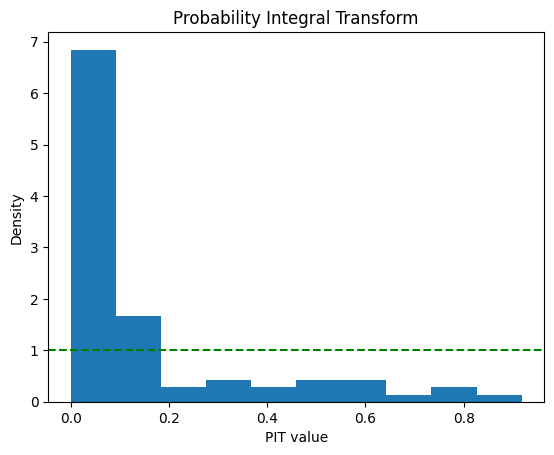

In [40]:
pit_values = jax.scipy.stats.norm.cdf(standardized_residuals)

plt.hist(pit_values, density = True)

plt.axhline(1.0, linestyle = "--", color = "green")

plt.xlabel("PIT value")
plt.ylabel("Density")
plt.title("Probability Integral Transform")

Instead of being approximately uniform, PIT distribution is concentrated around 0.5. That is the classic signature of an overdispersed predictive distribution

### Conclusion

Although the posterior mean closely follows the held-out observations and achieves strong point-prediction metrics, the uncertainty diagnostics reveal substantial overdispersion. The calibration curve lies above the ideal diagonal, while the standardized predictive residuals have standard deviation 0.38, considerably below the value of one expected under correct calibration. Similarly, the PIT values are concentrated around 0.5 rather than approximately uniformly distributed. Thus, the model provides accurate mean predictions but systematically overestimates predictive uncertainty.

## Model Experiment II: Quadratic Mean + Simpler Kernel

Let us try to make the model more simple by removing the general trend in kernel. Since it is already captured by the mean function, it is not necessary to include it in the kernel. Also let us try quadratic mean function so that it can capture some curvature if there is any. So, the model for this section is:
$$ m(x) = \beta_0 + \beta_1 x + \beta_2 x^2 $$
$$ k(x, x') = k_{\text{periodic}}(x, x') + k_{\text{local}}(x, x') $$

periodic and local kernels will stay the same being Sine-Squared and Matern 3/2 kernels.

For numerical stability, the inputs to the quadratic kernel were standardized, since the gradient with respect to $\beta_2$ contains $x^2$ term, which can blow up the gradients if raw values of $x$ are used. 

In [41]:
x_mean = jnp.mean(x_train)
x_std = jnp.std(x_train)

def quadratic_mean(x: jnp.ndarray, a: float, b: float, c: float) -> jnp.ndarray:
    z = (x - x_mean) / x_std
    return (a + b * z + c * z**2).reshape(-1)

def simpler_composite_kernel(a: jnp.ndarray, 
                             b: jnp.ndarray, 
                             theta_periodic: float,
                             ell_periodic: float,
                             theta_local: float,
                             ell_local: float) -> jnp.ndarray:
    return (sin_kernel(a, b, theta = theta_periodic, ell = ell_periodic) +
            matern_kernel(a, b, theta = theta_local, ell = ell_local))

def negative_marginal_log_likelihood(x: jnp.ndarray, 
                                     y: jnp.ndarray,
                                     beta0: float,
                                     beta1: float,
                                     beta2: float,
                                     log_theta_periodic: float,
                                     log_ell_periodic: float,
                                     log_theta_local: float,
                                     log_ell_local: float,
                                     log_noise_std: float) -> float:
    
    theta_periodic = jnp.exp(log_theta_periodic)
    ell_periodic = jnp.exp(log_ell_periodic)
    theta_local = jnp.exp(log_theta_local)
    ell_local = jnp.exp(log_ell_local)
    noise_std = jnp.exp(log_noise_std)

    m = quadratic_mean(x, beta0, beta1, beta2)
    K = simpler_composite_kernel(phi(x)[:, None, :], 
                                 phi(x)[None, :, :], 
                                 theta_periodic = theta_periodic, ell_periodic = ell_periodic,
                                 theta_local = theta_local, ell_local = ell_local) + (noise_std**2 + 1e-6) * jnp.eye(x.shape[0])
    L = jax.scipy.linalg.cho_factor(K, lower = True)

    model_fit = 1/2 * (y - m).T @ jax.scipy.linalg.cho_solve(L, y - m)
    complexity = jnp.sum(jnp.log(jnp.diag(L[0])))
    normalization = 1/2 * x.shape[0] * jnp.log(2 * jnp.pi)

    return model_fit + complexity + normalization

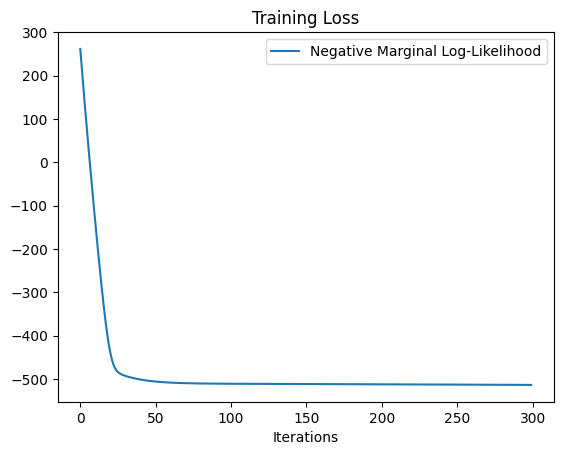

In [42]:
beta0 = 0.0
beta1 = 0.0
beta2 = 0.0

log_theta_periodic = 0.0
log_ell_periodic = 0.0

log_theta_local = 0.0
log_ell_local = 0.0

log_noise_std = 0.0

n_iter = 300
training_loss = []

best_loss = float("inf")
best_beta0 = 0.0
best_beta1 = 0.0
best_beta2 = 0.0
best_log_theta_periodic = 0.0
best_log_ell_periodic = 0.0
best_log_theta_local = 0.0
best_log_ell_local = 0.0
best_log_noise_std = 0.0

learning_rate = 0.001

for i in range(n_iter):
    loss = negative_marginal_log_likelihood(x_train, y_train, 
                                            beta0, beta1, beta2,
                                            log_theta_periodic, log_ell_periodic,
                                            log_theta_local, log_ell_local,
                                            log_noise_std)
    training_loss.append(loss)

    if loss < best_loss:
        best_loss = loss
        best_beta0 = beta0
        best_beta1 = beta1
        best_beta2 = beta2
        best_log_theta_periodic = log_theta_periodic
        best_log_ell_periodic = log_ell_periodic
        best_log_theta_local = log_theta_local
        best_log_ell_local = log_ell_local
        best_log_noise_std = log_noise_std

    grads = jax.grad(negative_marginal_log_likelihood, 
                     argnums = (2, 3, 4, 5, 6, 7, 8, 9))(x_train, y_train,
                                                         beta0, beta1, beta2,
                                                         log_theta_periodic, log_ell_periodic,
                                                         log_theta_local, log_ell_local,
                                                         log_noise_std)

    beta0 -= learning_rate * grads[0]
    beta1 -= learning_rate * grads[1]
    beta2 -= learning_rate * grads[2]
    log_theta_periodic -= learning_rate * grads[3]
    log_ell_periodic -= learning_rate * grads[4]
    log_theta_local -= learning_rate * grads[5]
    log_ell_local -= learning_rate * grads[6]
    log_noise_std -= learning_rate * grads[7]

beta0 = best_beta0
beta1 = best_beta1
beta2 = best_beta2
theta_periodic = jnp.exp(best_log_theta_periodic)
ell_periodic = jnp.exp(best_log_ell_periodic)
theta_local = jnp.exp(best_log_theta_local)
ell_local = jnp.exp(best_log_ell_local)
noise_std = jnp.exp(best_log_noise_std)

plt.plot(training_loss, label = "Negative Marginal Log-Likelihood")
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.legend()

<Axes: title={'center': 'Posterior with Optimal Hyperparameters'}>

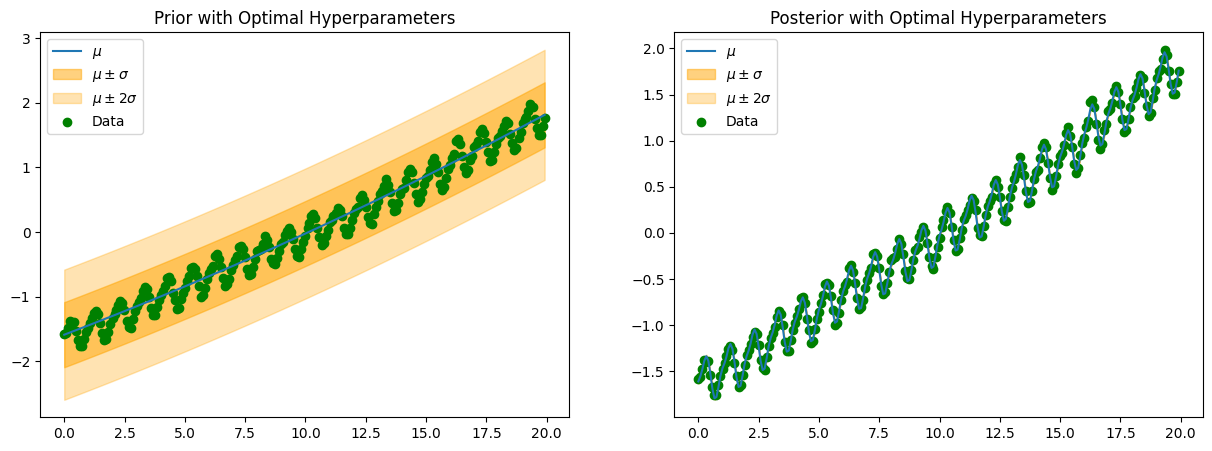

In [43]:
prior = GaussianProcess(lambda x: quadratic_mean(x, beta0, beta1, beta2), 
                        lambda a, b: simpler_composite_kernel(a, b, 
                                                              theta_periodic = theta_periodic, ell_periodic = ell_periodic,
                                                              theta_local = theta_local, ell_local = ell_local))

posterior = prior.condition(y_train, phi(x_train), noise_std**2 * jnp.eye(x_train.shape[0]))

pred_mean_prior = prior(phi(x_train)).mu
pred_var_prior = jnp.diag(prior(phi(x_train)).Sigma)

pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_train, pred_mean_prior, pred_var_prior, (x_train, y_train), title = r"Prior with Optimal Hyperparameters", ax = axes[0])
plot_posterior_predictive(x_train, pred_mean_post, pred_var_post, (x_train, y_train), title = r"Posterior with Optimal Hyperparameters", ax = axes[1])

Text(0.5, 1.0, 'GP Regression on Train, Test, and Future Data')

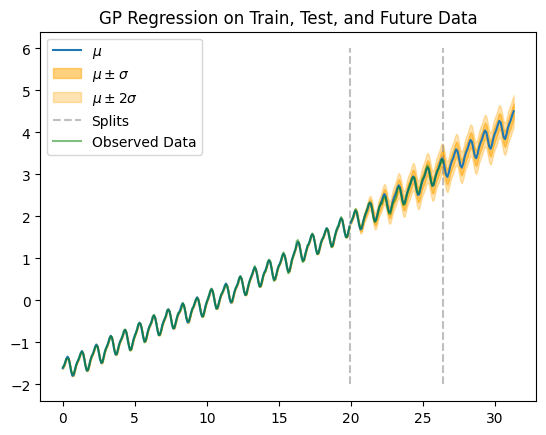

In [44]:
x_plot = jnp.arange(max(x_test), max(x_test) + 5, 0.1)

pred_mean_train = posterior._mean(phi(x_train))
pred_var_train = posterior._covariance(phi(x_train), phi(x_train))

pred_mean_test = posterior._mean(phi(x_test))
pred_var_test = posterior._covariance(phi(x_test), phi(x_test))

pred_mean_plot = posterior._mean(phi(x_plot))
pred_var_plot = posterior._covariance(phi(x_plot), phi(x_plot))

plt.plot(x_train, pred_mean_train, label = r"$\mu$", color = "tab:blue")
plt.fill_between(x_train, 
                pred_mean_train - jnp.sqrt(pred_var_train), 
                pred_mean_train + jnp.sqrt(pred_var_train),
                alpha=0.5,
                color="orange",
                label=r"$\mu \pm \sigma$")

plt.fill_between(x_train, 
                pred_mean_train - 2 * jnp.sqrt(pred_var_train), 
                pred_mean_train + 2 * jnp.sqrt(pred_var_train),
                alpha=0.3,
                color="orange",
                label=r"$\mu \pm 2\sigma$")

plt.vlines(x_train[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", label = "Splits", alpha = 0.5)

plt.plot(x_test, pred_mean_test, color = "tab:blue")
plt.fill_between(x_test, 
                pred_mean_test - jnp.sqrt(pred_var_test), 
                pred_mean_test + jnp.sqrt(pred_var_test),
                alpha=0.5,
                color="orange")

plt.fill_between(x_test, 
                pred_mean_test - 2 * jnp.sqrt(pred_var_test), 
                pred_mean_test + 2 * jnp.sqrt(pred_var_test),
                alpha=0.3,
                color="orange")

plt.vlines(x_test[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", alpha = 0.5)

plt.plot(x_plot, pred_mean_plot, color = "tab:blue")
plt.fill_between(x_plot, 
                pred_mean_plot - jnp.sqrt(pred_var_plot), 
                pred_mean_plot + jnp.sqrt(pred_var_plot),
                alpha=0.5,
                color="orange")

plt.plot(x_train, y_train, color = "green", label = "Observed Data", alpha = 0.5)
plt.plot(x_test, y_test, color = "green", alpha = 0.5)

plt.fill_between(x_plot, 
                pred_mean_plot - 2 * jnp.sqrt(pred_var_plot), 
                pred_mean_plot + 2 * jnp.sqrt(pred_var_plot),
                alpha=0.3,
                color="orange")

plt.legend()
plt.title("GP Regression on Train, Test, and Future Data")

Posterior for the second model looks fine as well, but let us check the metrics to ensure that the model is doing well.

## Evaluation of Model II

In [45]:
pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train)) + noise_std**2

train_metrics = evaluate_model(y_train, pred_mean_post, pred_var_post)

print("Train Data:")
for i in train_metrics:
    print(f"{i}: {train_metrics[i]:.4f}")

Train Data:
R2: 0.9996
RMSE: 0.0196
NLPD: -2.4942
Coverage: 0.9708
Mean Interval Width: 0.0893


In [46]:
pred_mean_post = posterior._mean(phi(x_test))
pred_var_post = posterior._covariance(phi(x_test), phi(x_test)) + noise_std**2

test_metrics = evaluate_model(y_test, pred_mean_post, pred_var_post)

print("Test Data:")
for i in test_metrics:
    print(f"{i}: {test_metrics[i]:.4f}") 

Test Data:
R2: 0.9919
RMSE: 0.0384
NLPD: -1.1449
Coverage: 1.0000
Mean Interval Width: 0.5122


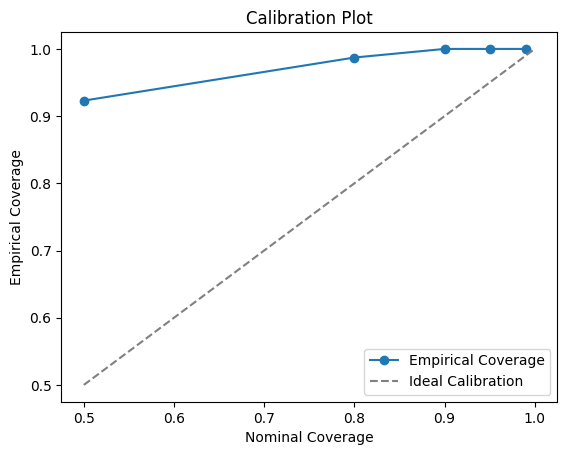

In [47]:
levels = [0.50, 0.80, 0.90, 0.95, 0.99]

calibration_results = []

for level in levels:
    empirical_coverage = coverage(
        y_test,
        pred_mean_post,
        pred_var_post,
        alpha=level,
    )

    interval_width = mean_interval_width(
        pred_var_post,
        alpha=level,
    )

    calibration_results.append({
        "Nominal": level,
        "Empirical": float(empirical_coverage),
        "Mean width": float(interval_width),
    })

plt.plot([res["Nominal"] for res in calibration_results],
         [res["Empirical"] for res in calibration_results],
         marker="o", label="Empirical Coverage")

plt.plot([0.5, 1], [0.5, 1], linestyle="--", color="gray", label="Ideal Calibration")
plt.title("Calibration Plot")
plt.xlabel("Nominal Coverage")
plt.ylabel("Empirical Coverage")
plt.legend()

In [48]:
standardized_residuals = (
    y_test - pred_mean_post
) / jnp.sqrt(pred_var_post)

print(f"Mean standardized residual: {jnp.mean(standardized_residuals):.4f}")
print(f"Std standardized residual: {jnp.std(standardized_residuals):.4f}")

Mean standardized residual: 0.0020
Std standardized residual: 0.3804


Text(0.5, 1.0, 'Probability Integral Transform')

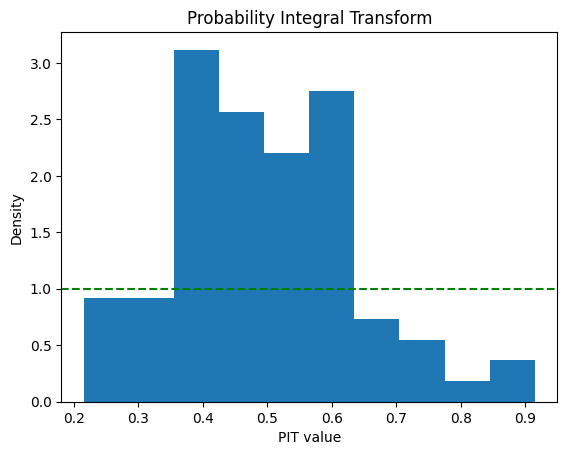

In [49]:
pit_values = jax.scipy.stats.norm.cdf(standardized_residuals)

plt.hist(pit_values, density = True)

plt.axhline(1.0, linestyle = "--", color = "green")

plt.xlabel("PIT value")
plt.ylabel("Density")
plt.title("Probability Integral Transform")

The results got better compared to the first model in both point predictions and uncertainty estimations. However, the results are still not convincing, latent pointwise variance is still too large, making the uncertainty bounds too wide.

## Model Experiment III: Periodic Kernel

Now let us try to use only periodic kernel

In [50]:
def negative_marginal_log_likelihood(x: jnp.ndarray, 
                                     y: jnp.ndarray,
                                     beta0: float,
                                     beta1: float,
                                     beta2: float,
                                     log_theta_periodic: float,
                                     log_ell_periodic: float,
                                     log_noise_std: float) -> float:
    
    theta_periodic = jnp.exp(log_theta_periodic)
    ell_periodic = jnp.exp(log_ell_periodic)
    noise_std = jnp.exp(log_noise_std)

    m = quadratic_mean(x, beta0, beta1, beta2)
    K = sin_kernel(phi(x)[:, None, :], 
                   phi(x)[None, :, :], 
                   theta = theta_periodic, ell = ell_periodic) + (noise_std**2 + 1e-6) * jnp.eye(x.shape[0])
    L = jax.scipy.linalg.cho_factor(K, lower = True)

    model_fit = 1/2 * (y - m).T @ jax.scipy.linalg.cho_solve(L, y - m)
    complexity = jnp.sum(jnp.log(jnp.diag(L[0])))
    normalization = 1/2 * x.shape[0] * jnp.log(2 * jnp.pi)

    return model_fit + complexity + normalization

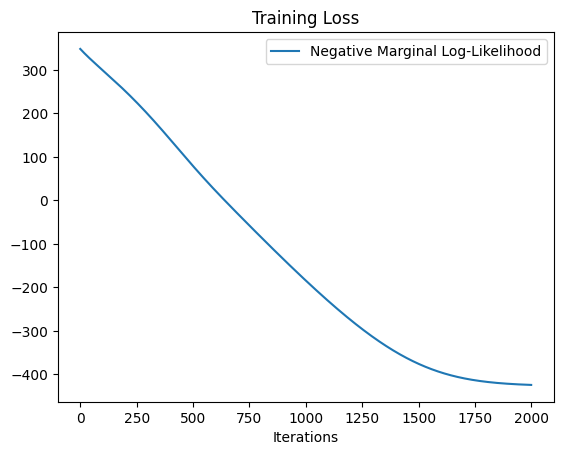

In [51]:
beta0 = 0.0
beta1 = 0.0
beta2 = 0.0

log_theta_periodic = 0.0
log_ell_periodic = 0.0

log_noise_std = 0.0

n_iter = 2000
training_loss = []

best_loss = float("inf")
best_beta0 = 0.0
best_beta1 = 0.0
best_beta2 = 0.0
best_log_theta_periodic = 0.0
best_log_ell_periodic = 0.0
best_log_noise_std = 0.0

learning_rate = 1e-5

for i in range(n_iter):
    loss = negative_marginal_log_likelihood(x_train, y_train, 
                                            beta0, beta1, beta2,
                                            log_theta_periodic, log_ell_periodic,
                                            log_noise_std)
    training_loss.append(loss)

    if loss < best_loss:
        best_loss = loss
        best_beta0 = beta0
        best_beta1 = beta1
        best_beta2 = beta2
        best_log_theta_periodic = log_theta_periodic
        best_log_ell_periodic = log_ell_periodic
        best_log_noise_std = log_noise_std

    grads = jax.grad(negative_marginal_log_likelihood, 
                     argnums = (2, 3, 4, 5, 6, 7))(x_train, y_train,
                                                   beta0, beta1, beta2,
                                                   log_theta_periodic, log_ell_periodic,
                                                   log_noise_std)

    beta0 -= learning_rate * grads[0]
    beta1 -= learning_rate * grads[1]
    beta2 -= learning_rate * grads[2]
    log_theta_periodic -= learning_rate * grads[3]
    log_ell_periodic -= learning_rate * grads[4]
    log_noise_std -= learning_rate * grads[5]

beta0 = best_beta0
beta1 = best_beta1
beta2 = best_beta2
theta_periodic = jnp.exp(best_log_theta_periodic)
ell_periodic = jnp.exp(best_log_ell_periodic)
noise_std = jnp.exp(best_log_noise_std)

plt.plot(training_loss, label = "Negative Marginal Log-Likelihood")
plt.title("Training Loss")
plt.xlabel("Iterations")
plt.legend()

<Axes: title={'center': 'Posterior with Optimal Hyperparameters'}>

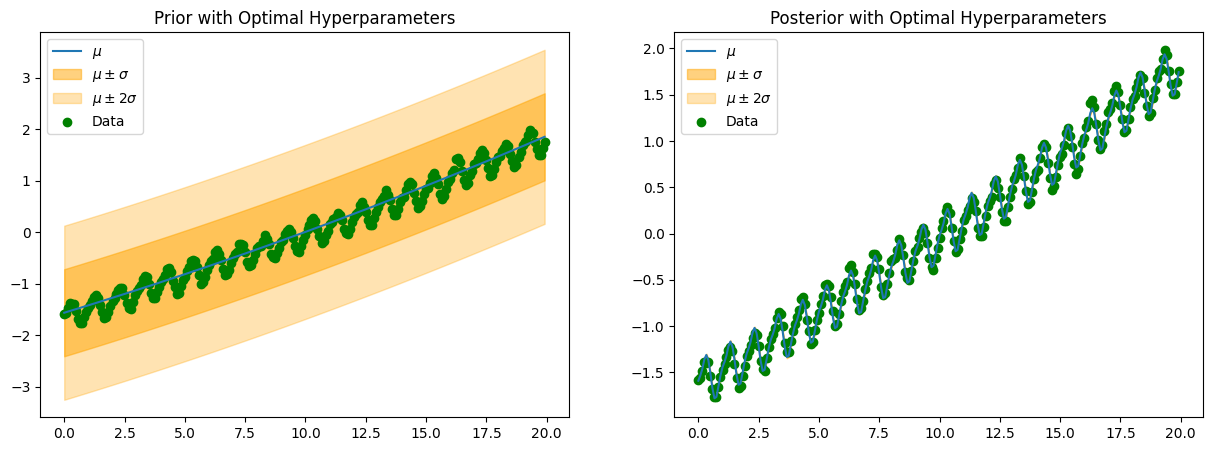

In [52]:
prior = GaussianProcess(lambda x: quadratic_mean(x, beta0, beta1, beta2), 
                        lambda a, b: sin_kernel(a, b, 
                                                theta = theta_periodic, ell = ell_periodic))

posterior = prior.condition(y_train, phi(x_train), noise_std**2 * jnp.eye(x_train.shape[0]))

pred_mean_prior = prior(phi(x_train)).mu
pred_var_prior = jnp.diag(prior(phi(x_train)).Sigma)

pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train))

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (15, 5))

plot_posterior_predictive(x_train, pred_mean_prior, pred_var_prior, (x_train, y_train), title = r"Prior with Optimal Hyperparameters", ax = axes[0])
plot_posterior_predictive(x_train, pred_mean_post, pred_var_post, (x_train, y_train), title = r"Posterior with Optimal Hyperparameters", ax = axes[1])

Text(0.5, 1.0, 'GP Regression on Train, Test, and Future Data')

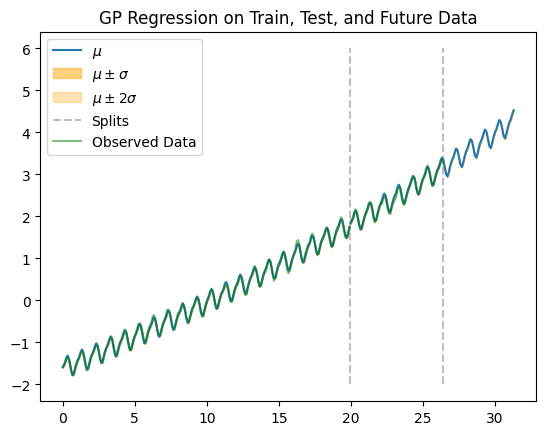

In [53]:
x_plot = jnp.arange(max(x_test), max(x_test) + 5, 0.1)

pred_mean_train = posterior._mean(phi(x_train))
pred_var_train = posterior._covariance(phi(x_train), phi(x_train))

pred_mean_test = posterior._mean(phi(x_test))
pred_var_test = posterior._covariance(phi(x_test), phi(x_test))

pred_mean_plot = posterior._mean(phi(x_plot))
pred_var_plot = posterior._covariance(phi(x_plot), phi(x_plot))

plt.plot(x_train, pred_mean_train, label = r"$\mu$", color = "tab:blue")
plt.fill_between(x_train, 
                pred_mean_train - jnp.sqrt(pred_var_train), 
                pred_mean_train + jnp.sqrt(pred_var_train),
                alpha=0.5,
                color="orange",
                label=r"$\mu \pm \sigma$")

plt.fill_between(x_train, 
                pred_mean_train - 2 * jnp.sqrt(pred_var_train), 
                pred_mean_train + 2 * jnp.sqrt(pred_var_train),
                alpha=0.3,
                color="orange",
                label=r"$\mu \pm 2\sigma$")

plt.vlines(x_train[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", label = "Splits", alpha = 0.5)

plt.plot(x_test, pred_mean_test, color = "tab:blue")
plt.fill_between(x_test, 
                pred_mean_test - jnp.sqrt(pred_var_test), 
                pred_mean_test + jnp.sqrt(pred_var_test),
                alpha=0.5,
                color="orange")

plt.fill_between(x_test, 
                pred_mean_test - 2 * jnp.sqrt(pred_var_test), 
                pred_mean_test + 2 * jnp.sqrt(pred_var_test),
                alpha=0.3,
                color="orange")

plt.vlines(x_test[-1], ymin = -2, ymax = 6, color = "gray", linestyle = "--", alpha = 0.5)

plt.plot(x_plot, pred_mean_plot, color = "tab:blue")
plt.fill_between(x_plot, 
                pred_mean_plot - jnp.sqrt(pred_var_plot), 
                pred_mean_plot + jnp.sqrt(pred_var_plot),
                alpha=0.5,
                color="orange")

plt.plot(x_train, y_train, color = "green", label = "Observed Data", alpha = 0.5)
plt.plot(x_test, y_test, color = "green", alpha = 0.5)

plt.fill_between(x_plot, 
                pred_mean_plot - 2 * jnp.sqrt(pred_var_plot), 
                pred_mean_plot + 2 * jnp.sqrt(pred_var_plot),
                alpha=0.3,
                color="orange")

plt.legend()
plt.title("GP Regression on Train, Test, and Future Data")

Posterior for the third model looks the best for now, the posterior uncertainty remains approximately constant beyond the training set. Let us see if the predictive variance got better.

## Evaluation of Model III

In [54]:
pred_mean_post = posterior._mean(phi(x_train))
pred_var_post = posterior._covariance(phi(x_train), phi(x_train)) + noise_std**2

train_metrics = evaluate_model(y_train, pred_mean_post, pred_var_post)

print("Train Data:")
for i in train_metrics:
    print(f"{i}: {train_metrics[i]:.4f}")

Train Data:
R2: 0.9987
RMSE: 0.0356
NLPD: -1.8998
Coverage: 0.9833
Mean Interval Width: 0.1591


In [55]:
pred_mean_post = posterior._mean(phi(x_test))
pred_var_post = posterior._covariance(phi(x_test), phi(x_test)) + noise_std**2

test_metrics = evaluate_model(y_test, pred_mean_post, pred_var_post)

print("Test Data:")
for i in test_metrics:
    print(f"{i}: {test_metrics[i]:.4f}") 

Test Data:
R2: 0.9899
RMSE: 0.0428
NLPD: -1.7300
Coverage: 0.9103
Mean Interval Width: 0.1591


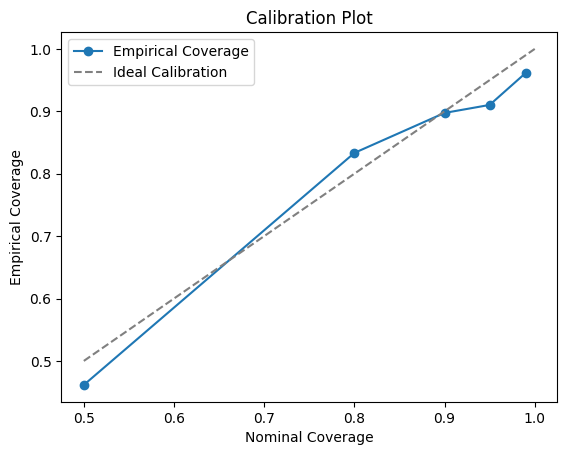

In [56]:
levels = [0.50, 0.80, 0.90, 0.95, 0.99]

calibration_results = []

for level in levels:
    empirical_coverage = coverage(
        y_test,
        pred_mean_post,
        pred_var_post,
        alpha=level,
    )

    interval_width = mean_interval_width(
        pred_var_post,
        alpha=level,
    )

    calibration_results.append({
        "Nominal": level,
        "Empirical": float(empirical_coverage),
        "Mean width": float(interval_width),
    })

plt.plot([res["Nominal"] for res in calibration_results],
         [res["Empirical"] for res in calibration_results],
         marker="o", label="Empirical Coverage")

plt.plot([0.5, 1], [0.5, 1], linestyle="--", color="gray", label="Ideal Calibration")
plt.title("Calibration Plot")
plt.xlabel("Nominal Coverage")
plt.ylabel("Empirical Coverage")
plt.legend()

In [57]:
standardized_residuals = (
    y_test - pred_mean_post
) / jnp.sqrt(pred_var_post)

print(f"Mean standardized residual: {jnp.mean(standardized_residuals):.4f}")
print(f"Std standardized residual: {jnp.std(standardized_residuals):.4f}")

Mean standardized residual: -0.3973
Std standardized residual: 0.9759


Text(0.5, 1.0, 'Probability Integral Transform')

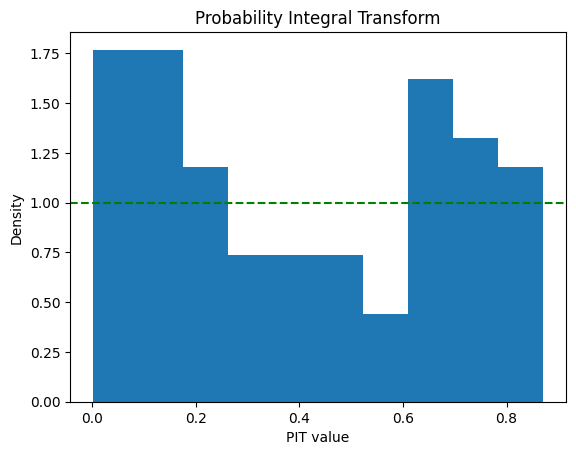

In [58]:
pit_values = jax.scipy.stats.norm.cdf(standardized_residuals)

plt.hist(pit_values, density = True)

plt.axhline(1.0, linestyle = "--", color = "green")

plt.xlabel("PIT value")
plt.ylabel("Density")
plt.title("Probability Integral Transform")

The simplified quadratic-mean and periodic-kernel model substantially improved uncertainty calibration. The standardized predictive residuals have standard deviation 0.98, close to the ideal value of one, and empirical interval coverage is reasonably aligned with nominal levels. However, their mean is −0.40, indicating moderate systematic overprediction. The model therefore estimates predictive dispersion well but exhibits a directional bias in its posterior mean. Also, because the quadratic mean parameters are treated as point estimates, uncertainty about long-term trend extrapolation is not represented.

## Note on Hyperparameter Initialization

Note that we have run an optimization on the linear and quadratic mean function coefficients as well as the logarithms of the hyperparameters of covariance kernels. This is not the best idea to pair with a constant learning rate since the parameters live on different scales. One might consider using Ordinary Least Squares (OLS) for the mean function coefficient initialization. That would make the job easier for the optimizer since it starts from already reasonable coefficient values. Even better, for fixed covariance hyperparameters, the optimal mean coefficients can be obtained directly using Generalized Least Squares (GLS):
$$ \hat{\beta}_{\text{GLS}} = (X^T K^{-1} X)^{-1} X^T K^{-1} y $$
Unlike OLS, GLS takes the covariance between the observations into account. Thus, instead of optimizing the mean coefficients together with the kernel hyperparameters, one can calculate their optimal GLS values for the current covariance parameters and only optimize the latter.

## Limitations

The results depend on the selected mean function, kernel, and hyperparameters. Hyperparameter uncertainty is not included, and the real-data experiment uses only one train-test split.

# Computational Complexity

For $n$ training observations, exact GP regression requires $O(n^2)$ memory and $O(n^3)$ time due to the Cholesky decomposition of the covariance matrix. This limits exact GP regression to moderately sized datasets.

# Conclusion

Gaussian process regression extends Gaussian conditioning to distributions over functions. It provides both point predictions and predictive uncertainty. The real-data example showed that strong point accuracy does not guarantee calibrated uncertainty, making coverage, standardized residuals, and PIT diagnostics important.